C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\3583300752.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: float(step_reward[g.index].sum()))\
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\3583300752.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: float(step_reward[g.index].sum()))\
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\3583300752.py:64: Deprecat

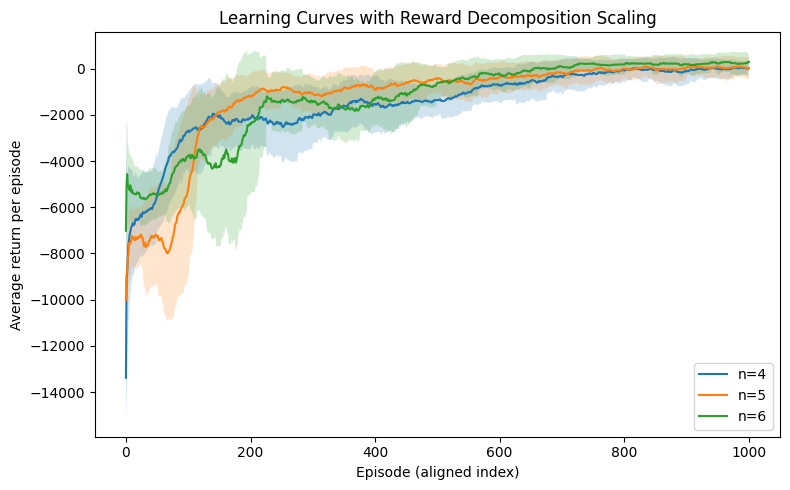

In [1]:
# Figure 5: Learning curves (average per-episode return) for n=4,5,6
# The script reads result4.csv, result5.csv, result6.csv and plots the learning curves
# with shaded standard deviation bands. Reward components are scaled by:
# [1., 1., 0., 10., 10., 10., 1., 1., 1.]

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- Config ----------
files = {
    4: "result4.csv",
    5: "result5.csv",
    6: "result6.csv",
}
reward_scale = np.array([1., 1., 0., 10., 10., 10., 1., 1., 1.], dtype=float)  # length 9 for comp1..comp9
rolling_window = 50  # episodes for smoothing

# ---------- Helpers ----------
comp_regex = re.compile(r"agent(\d+)_comp(\d+)$")

def infer_agent_count(df):
    agents = set()
    for col in df.columns:
        m = comp_regex.match(col)
        if m:
            agents.add(int(m.group(1)))
    return (max(agents) + 1) if agents else 0

def compute_episode_returns(df, expected_n=None):
    # Identify all comp columns
    comp_cols = [c for c in df.columns if comp_regex.match(c)]
    if not comp_cols:
        raise ValueError("No agent*_comp* columns found.")
    # Infer n if not provided
    n = infer_agent_count(df)
    if expected_n is not None and n != expected_n:
        # If mismatch, trust expected_n but warn by clipping to available
        n = expected_n

    # Build per-step total reward using reward_scale
    step_reward = np.zeros(len(df), dtype=float)
    for agent_idx in range(n):
        # Collect this agent's 9 components (comp1..comp9)
        comps = []
        for k in range(1, 10):
            col = f"agent{agent_idx}_comp{k}"
            if col in df.columns:
                comps.append(df[col].to_numpy())
            else:
                # Missing component => treat as zeros
                comps.append(np.zeros(len(df), dtype=float))
        comps = np.vstack(comps)  # shape (9, steps)
        # Apply scaling across the first axis (9,)
        scaled = (reward_scale[:, None] * comps).sum(axis=0)  # shape (steps,)
        step_reward += scaled

    # Aggregate per episode
    if "episode_id" not in df.columns:
        raise ValueError("Missing 'episode_id' column in CSV.")
    ep_returns = df.groupby("episode_id")\
                   .apply(lambda g: float(step_reward[g.index].sum()))\
                   .sort_index()
    return ep_returns

# ---------- Load, compute, collect ----------
returns_per_n = {}
for n, path in files.items():
    if not os.path.exists(path):
        print(f"WARNING: '{path}' not found. Skipping n={n}.")
        continue
    df = pd.read_csv(path)
    df=df[df['episode_id']<=1000]
    ep_returns = compute_episode_returns(df, expected_n=n)
    returns_per_n[n] = ep_returns

if not returns_per_n:
    raise SystemExit("No CSV files were found. Please place result4.csv, result5.csv, result6.csv in the working directory.")

# Align episode indices (assuming 0..999 or 1..1000); reindex to the union
all_episodes = sorted(set().union(*[s.index.tolist() for s in returns_per_n.values()]))
aligned = {}
for n, s in returns_per_n.items():
    aligned[n] = s.reindex(all_episodes)

# ---------- Plot ----------
plt.figure(figsize=(8, 5))

for n, s in aligned.items():
    # Rolling mean & std
    mean = s.rolling(window=rolling_window, min_periods=1).mean()
    std = s.rolling(window=rolling_window, min_periods=1).std().fillna(0.0)
    x = np.arange(len(mean))  # aligned episode index order
    plt.plot(x, mean.values, label=f"n={n}")
    plt.fill_between(x, (mean - std).values, (mean + std).values, alpha=0.2)

plt.xlabel("Episode (aligned index)")
plt.ylabel("Average return per episode")
plt.title("Learning Curves with Reward Decomposition Scaling")
plt.legend()
plt.tight_layout()

# Save figure
out_path = "figure5_learning_curve.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")


plt.show()


Saved: figure6_success_rate.png and figure6_success_rate.pdf


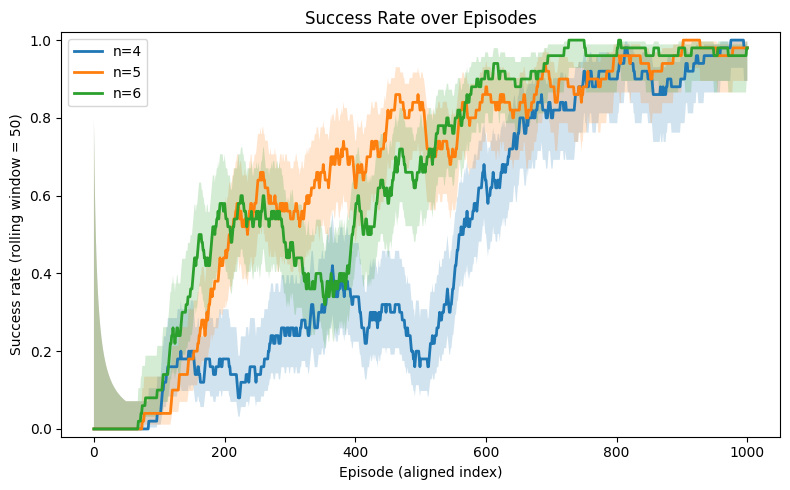

In [2]:
# figure6_success_rate.py
# Plot success rate over episodes from result4.csv, result5.csv, result6.csv
# Success criterion: episode is a success iff max(done_count) == n (all agents reached goals).
# Time-limit endings with done_count < n are counted as failures.

import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Config ----------
FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}
ROLLING_WINDOW = 50         # episodes for smoothing
CONF_LEVEL = 0.95           # CI for the shaded band
OUTPUT_PNG = "figure6_success_rate.png"
OUTPUT_PDF = "figure6_success_rate.pdf"

# ---------- Helpers ----------
def infer_n_from_columns(df: pd.DataFrame) -> int:
    """Infer agent count from columns like hung_dist_agent0 or agent3_vel_lin, etc."""
    patt = re.compile(r".*agent(\d+).*")
    agents = set()
    for c in df.columns:
        m = patt.match(c)
        if m:
            agents.add(int(m.group(1)))
    return (max(agents) + 1) if agents else int(df.get("done_count", pd.Series([np.nan])).max() or 0)

def per_episode_success_series(df: pd.DataFrame, expected_n: int) -> pd.Series:
    """
    Return a Series indexed by episode_id with values in {0,1},
    where 1 indicates the episode had max(done_count) == expected_n.
    """
    if "episode_id" not in df.columns or "done_count" not in df.columns:
        raise ValueError("CSV must contain 'episode_id' and 'done_count' columns.")
    # Make sure episode_id is sorted
    df_sorted = df.sort_values(["episode_id", "timestep" if "timestep" in df.columns else "total_step"])
    # For each episode, check whether done_count ever reaches n
    g = df_sorted.groupby("episode_id")["done_count"].max()
    success = (g >= expected_n).astype(int)
    success.name = "success"
    return success

def rolling_success_with_ci(success: pd.Series, window: int, conf: float):
    """
    Given a 0/1 Series by episode, compute rolling mean success and its (Wald) CI.
    Returns (mean, lower, upper, count) aligned to the series index order.
    """
    # Rolling counts and means
    count = success.rolling(window=window, min_periods=1).count()
    p = success.rolling(window=window, min_periods=1).mean()

    # Standard error for binomial proportion
    se = np.sqrt((p * (1 - p)) / np.maximum(count, 1))
    # z for two-sided CI
    from scipy.stats import norm
    z = norm.ppf(0.5 + conf/2.0)
    lower = (p - z * se).clip(0.0, 1.0)
    upper = (p + z * se).clip(0.0, 1.0)
    return p, lower, upper, count

def rolling_success_with_ci_wilson(success, window=50, conf=0.95):
    import numpy as np
    from scipy.stats import norm
    z = norm.ppf(0.5 + conf/2.0)

    # rolling counts and sums
    roll_count = success.rolling(window=window, min_periods=1).count()
    roll_sum   = success.rolling(window=window, min_periods=1).sum()
    p̂ = roll_sum / np.maximum(roll_count, 1)

    n = np.maximum(roll_count, 1)
    denom = 1 + z**2/n
    center = p̂ + z**2/(2*n)
    margin = z*np.sqrt((p̂*(1-p̂) + z**2/(4*n))/n)
    lower = (center - margin)/denom
    upper = (center + margin)/denom
    return p̂.clip(0,1), lower.clip(0,1), upper.clip(0,1), roll_count

# ---------- Load and compute ----------
series_by_n = {}
for n, path in FILES.items():
    if not os.path.exists(path):
        print(f"WARNING: '{path}' not found. Skipping n={n}.")
        continue
    df = pd.read_csv(path)
    df=df[df['episode_id']<=1000]
    inferred = infer_n_from_columns(df)
    if inferred and inferred != n:
        print(f"Note: inferred n={inferred} from columns in {path}; using expected n={n} from filename.")
    s = per_episode_success_series(df, expected_n=n).sort_index()
    series_by_n[n] = s

if not series_by_n:
    raise SystemExit("No CSV files were found. Place result4.csv, result5.csv, result6.csv next to this script and rerun.")

# Align episodes (union of indices)
all_eps = sorted(set().union(*[s.index.tolist() for s in series_by_n.values()]))
aligned = {n: s.reindex(all_eps) for n, s in series_by_n.items()}

# ---------- Plot ----------
plt.figure(figsize=(8, 5))

for n, s in aligned.items():
    # Compute rolling success rate and 95% CI
    mean, lo, hi, cnt = rolling_success_with_ci_wilson(s, window=ROLLING_WINDOW, conf=CONF_LEVEL)
    x = np.arange(len(mean))
    plt.plot(x, mean.values, label=f"n={n}", linewidth=2.0)
    plt.fill_between(x, lo.values, hi.values, alpha=0.2)

plt.ylim(-0.02, 1.02)
plt.xlabel("Episode (aligned index)")
plt.ylabel(f"Success rate (rolling window = {ROLLING_WINDOW})")
plt.title("Success Rate over Episodes")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=200, bbox_inches="tight")
plt.savefig(OUTPUT_PDF, bbox_inches="tight")
print(f"Saved: {OUTPUT_PNG} and {OUTPUT_PDF}")
plt.show()

C:\Users\abzza\AppData\Local\Temp\ipykernel_20840\403525704.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(first_success_ts)
C:\Users\abzza\AppData\Local\Temp\ipykernel_20840\403525704.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(first_success_ts)
C:\Users\abzza\AppData\Local\Temp\ipykernel_20840\403525704.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping

Saved: figure7_completion_time_boxplot.png and figure7_completion_time_boxplot.pdf
n=4: successes 1005/1525 | median=70, IQR=[35, 156], mean=116.7, std=113.4
n=5: successes 1761/2091 | median=55, IQR=[34, 111], mean=93.3, std=96.0
n=6: successes 1816/2141 | median=40, IQR=[27, 76], mean=74.6, std=87.0


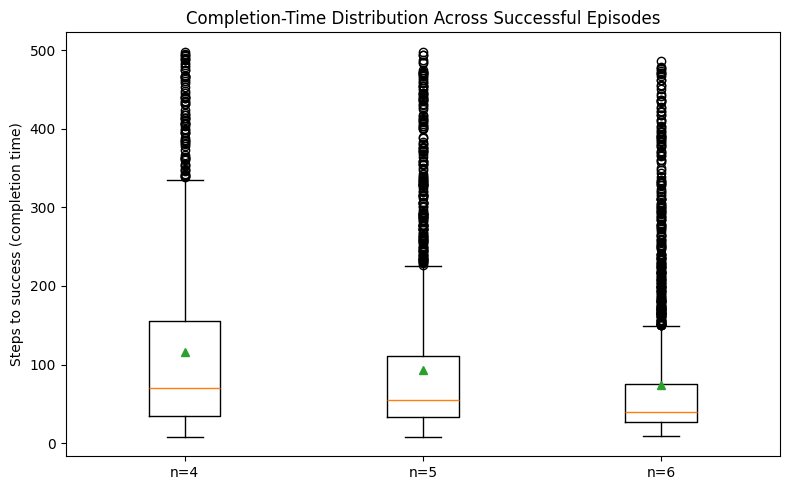

In [6]:
# Jupyter cell — Figure 7: Completion-time distribution (boxplot) for n = 4, 5, 6
# Inputs: result4.csv, result5.csv, result6.csv (schema as described)
# Success criterion: an episode is successful iff `done_count` reaches n at any timestep.
# Completion time: first `timestep` where `done_count == n`.
# Outputs: figure7_completion_time_boxplot.png (600 dpi) and figure7_completion_time_boxplot.pdf

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- Config --------
FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}
OUTPUT_PNG = "figure7_completion_time_boxplot.png"
OUTPUT_PDF = "figure7_completion_time_boxplot.pdf"

def completion_times_from_csv(path: str, n: int):
    """
    Compute completion times for successful episodes in a single CSV.
    Success = any step in episode where done_count == n.
    Completion time = earliest timestep with done_count == n.
    Returns (list_of_completion_times, total_episode_count).
    """
    df = pd.read_csv(path)
    df=df[df['episode_id']<=1000]
    required = {"episode_id", "done_count", "timestep"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns: {sorted(missing)}")

    # Ensure chronological order within each episode
    df = df.sort_values(["episode_id", "timestep"]).reset_index(drop=True)

    total_eps = int(df["episode_id"].nunique())

    def first_success_ts(g: pd.DataFrame):
        idx = g.index[g["done_count"] >= n]
        if len(idx) == 0:
            return np.nan  # failure episode (e.g., time limit)
        return int(g.loc[idx[0], "timestep"])

    comp_times = (
        df.groupby("episode_id", sort=True)
          .apply(first_success_ts)
          .dropna()
          .astype(int)
          .tolist()
    )
    return comp_times, total_eps

# -------- Compute --------
data = {}
totals = {}
for n, path in FILES.items():
    if not os.path.exists(path):
        print(f"WARNING: '{path}' not found. Skipping n={n}.")
        continue
    comp_times, total_eps = completion_times_from_csv(path, n)
    data[n] = comp_times
    totals[n] = total_eps

if not data:
    raise SystemExit("No CSV files were found. Place result4.csv, result5.csv, result6.csv and rerun this cell.")

# -------- Plot --------
labels = []
box_data = []
for n in sorted(data.keys()):
    labels.append(f"n={n}")
    box_data.append(data[n])

plt.figure(figsize=(8, 5))
plt.boxplot(box_data, labels=labels, showmeans=True)
plt.ylabel("Steps to success (completion time)")
plt.title("Completion-Time Distribution Across Successful Episodes")
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=600, bbox_inches="tight")  # high-res raster
plt.savefig(OUTPUT_PDF, bbox_inches="tight")           # vector for paper
print(f"Saved: {OUTPUT_PNG} and {OUTPUT_PDF}")

# Optional: print a quick summary
for n in sorted(data.keys()):
    arr = np.array(data[n], dtype=float)
    if arr.size == 0:
        print(f"n={n}: no successful episodes")
        continue
    q1, med, q3 = np.percentile(arr, [25, 50, 75])
    print(f"n={n}: successes {arr.size}/{totals.get(n,'?')} | "
          f"median={med:.0f}, IQR=[{q1:.0f}, {q3:.0f}], mean={arr.mean():.1f}, std={arr.std(ddof=1):.1f}")
plt.show()

C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\1547210764.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  s = df.groupby("episode_id").apply(first_success_ts).sort_index()
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\1547210764.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  s = df.groupby("episode_id").apply(first_success_ts).sort_index()
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\

Saved: figure7a_completion_time_violin.png, figure7a_completion_time_violin.pdf


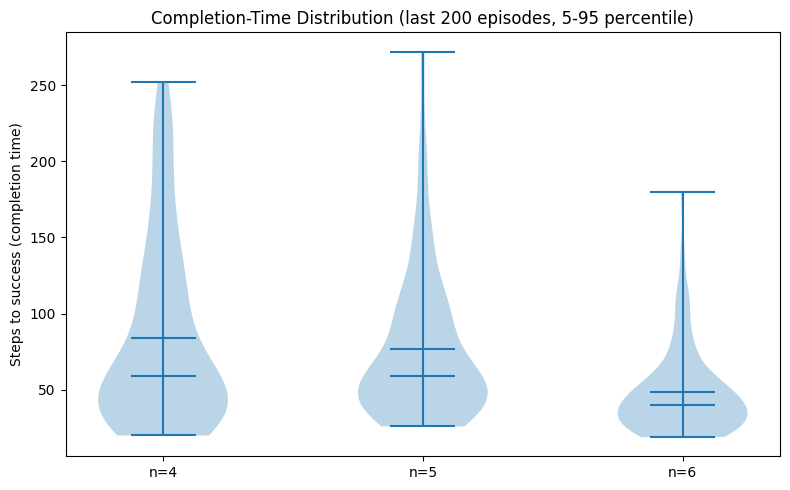

In [3]:
# Figure 7A: Completion-time violin plot (final episodes, trimmed)
# Inputs: result4.csv, result5.csv, result6.csv
# Success = first timestep where done_count == n.
# Uses only the last K episodes to reflect steady-state; trims 5–95% to reduce clutter.
# Outputs: figure7a_completion_time_violin.png/.pdf

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}
LAST_EPISODES = 200        # use only the last K episodes per n
TRIM_LOW, TRIM_HIGH = 5, 95
OUT_PNG = "figure7a_completion_time_violin.png"
OUT_PDF = "figure7a_completion_time_violin.pdf"

def success_time_series(df, n):
    if not {"episode_id","timestep","done_count"} <= set(df.columns):
        raise ValueError("CSV must contain episode_id, timestep, done_count")
    df = df.sort_values(["episode_id","timestep"]).reset_index(drop=True)
    # earliest timestep per episode where done_count == n
    def first_success_ts(g):
        idx = g.index[g["done_count"] >= n]
        if len(idx)==0: return np.nan
        return int(g.loc[idx[0], "timestep"])
    s = df.groupby("episode_id").apply(first_success_ts).sort_index()
    return s  # index: episode_id, values: timestep or NaN

def last_k_episode_ids(df, k):
    eps = np.array(sorted(df["episode_id"].unique()))
    return eps[-k:] if len(eps) >= k else eps

def trimmed(arr, low=5, high=95):
    if len(arr)==0: return arr
    lo, hi = np.percentile(arr, [low, high])
    return arr[(arr >= lo) & (arr <= hi)]

data = {}
labels = []
for n, path in FILES.items():
    if not os.path.exists(path):
        print(f"WARNING: {path} not found; skipping n={n}")
        continue
    df = pd.read_csv(path)
    df=df[df['episode_id']<=1000]
    keep_eps = last_k_episode_ids(df, LAST_EPISODES)
    df_last = df[df["episode_id"].isin(keep_eps)]
    s = success_time_series(df_last, n)
    # keep only successful episodes
    ct = s.dropna().astype(int).values
    ct = trimmed(ct, TRIM_LOW, TRIM_HIGH)
    data[n] = ct
    labels.append(f"n={n}")

# Plot
plt.figure(figsize=(8,5))
vp = plt.violinplot([data[n] for n in sorted(data.keys())],
                    showmeans=True, showmedians=True)
plt.xticks(range(1, len(data)+1), [f"n={n}" for n in sorted(data.keys())])
plt.ylabel("Steps to success (completion time)")
plt.title(f"Completion-Time Distribution (last {LAST_EPISODES} episodes, {TRIM_LOW}-{TRIM_HIGH} percentile)")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=600, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")
print(f"Saved: {OUT_PNG}, {OUT_PDF}")



C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\694871912.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  s = df.groupby("episode_id").apply(first_success_ts).sort_index()
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\694871912.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  s = df.groupby("episode_id").apply(first_success_ts).sort_index()
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\69

Saved: figure7b_cumulative_completion_probability.png, figure7b_cumulative_completion_probability.pdf


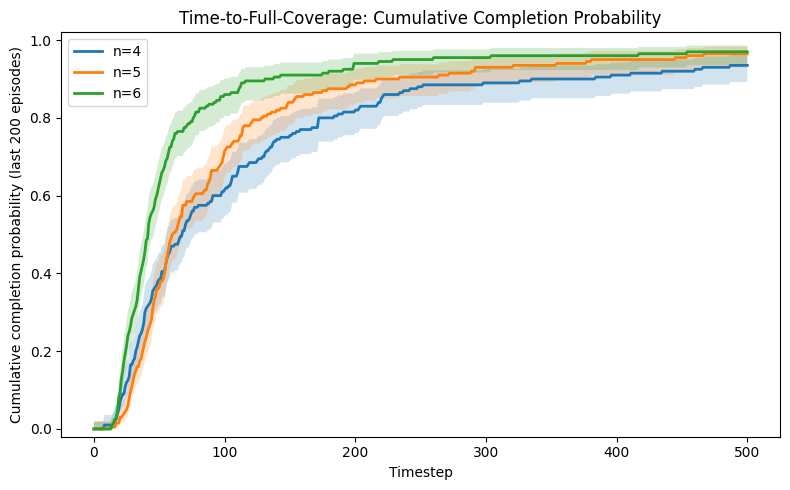

In [4]:
# Figure 7B: Cumulative completion probability vs. timestep (final episodes)
# For each timestep t, we plot P(episode completed by t). Failures simply never contribute.
# Wilson 95% CI shown as a ribbon. Outputs PNG/PDF.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from scipy.stats import norm

FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}
LAST_EPISODES = 200
OUT_PNG = "figure7b_cumulative_completion_probability.png"
OUT_PDF = "figure7b_cumulative_completion_probability.pdf"
CONF = 0.95

def success_time_series(df, n):
    if not {"episode_id","timestep","done_count"} <= set(df.columns):
        raise ValueError("CSV must contain episode_id, timestep, done_count")
    df = df.sort_values(["episode_id","timestep"]).reset_index(drop=True)
    def first_success_ts(g):
        idx = g.index[g["done_count"] >= n]
        if len(idx)==0: return np.nan
        return int(g.loc[idx[0], "timestep"])
    s = df.groupby("episode_id").apply(first_success_ts).sort_index()
    return s  # NaN = failure

def last_k_episode_ids(df, k):
    eps = np.array(sorted(df["episode_id"].unique()))
    return eps[-k:] if len(eps) >= k else eps

def wilson_ci(k, n, conf=0.95):
    if n <= 0: return (0.0, 0.0, 0.0)
    z = norm.ppf(0.5 + conf/2)
    p = k / n
    denom = 1 + z*z/n
    center = p + z*z/(2*n)
    margin = z*sqrt((p*(1-p) + z*z/(4*n))/n)
    lo = (center - margin)/denom
    hi = (center + margin)/denom
    return (p, max(0.0, lo), min(1.0, hi))

curves = {}  # n -> dict with t, p, lo, hi
for n, path in FILES.items():
    if not os.path.exists(path):
        print(f"WARNING: {path} not found; skipping n={n}")
        continue
    df = pd.read_csv(path)
    df=df[df['episode_id']<=1000]
    keep_eps = last_k_episode_ids(df, LAST_EPISODES)
    df_last = df[df["episode_id"].isin(keep_eps)]
    s = success_time_series(df_last, n)
    # time limit inferred from per-episode max timestep
    tmax = int(df_last.groupby("episode_id")["timestep"].max().max())
    times = s.values  # shape (episodes,)
    # convert NaN (failures) to +inf so they never count as completed by t
    times = np.where(np.isnan(times), np.inf, times)
    t_grid = np.arange(0, tmax+1, 1)
    n_eps = len(times)
    p_list, lo_list, hi_list = [], [], []
    for t in t_grid:
        k = int(np.sum(times <= t))
        p, lo, hi = wilson_ci(k, n_eps, conf=CONF)
        p_list.append(p); lo_list.append(lo); hi_list.append(hi)
    curves[n] = {"t": t_grid, "p": np.array(p_list), "lo": np.array(lo_list), "hi": np.array(hi_list)}

# Plot
plt.figure(figsize=(8,5))
for n in sorted(curves.keys()):
    C = curves[n]
    plt.plot(C["t"], C["p"], label=f"n={n}", linewidth=2)
    plt.fill_between(C["t"], C["lo"], C["hi"], alpha=0.2)
plt.ylim(-0.02, 1.02)
plt.xlabel("Timestep")
plt.ylabel(f"Cumulative completion probability (last {LAST_EPISODES} episodes)")
plt.title("Time-to-Full-Coverage: Cumulative Completion Probability")
plt.tight_layout()
plt.legend()
plt.savefig(OUT_PNG, dpi=600, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")
print(f"Saved: {OUT_PNG}, {OUT_PDF}")


Saved: figure8_done_progression.png, figure8_done_progression.pdf


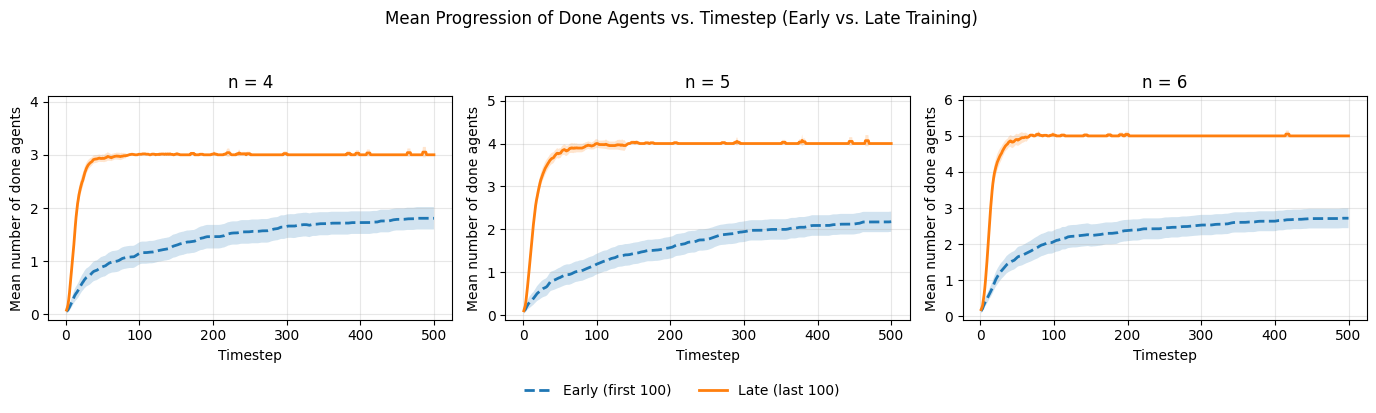

In [5]:
# Jupyter cell — Figure 8: Mean progression of “done” agents vs. timestep
# Compares early vs. late training for n = 4, 5, 6 using result4.csv, result5.csv, result6.csv.
# Success flag is *not* used here; we simply average `done_count` per timestep.
# “Early” = first EARLY_EP episodes; “Late” = last LATE_EP episodes (per n).
# Saves both PNG and PDF.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Config ----------------
FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}

EARLY_EP = 100   # number of earliest episodes to average
LATE_EP  = 100   # number of latest episodes to average

NORMALIZE_TO_FRACTION = False  # if True, divide curves by n so y in [0,1]
SMOOTH_WINDOW = 5              # rolling window across timesteps (set to 1 to disable)

OUT_PNG = "figure8_done_progression.png"
OUT_PDF = "figure8_done_progression.pdf"

# -------------- Helpers -----------------
REQUIRED_COLS = {"episode_id", "timestep", "done_count"}

def ensure_columns(df, path):
    missing = REQUIRED_COLS - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns: {sorted(missing)}")

def pick_early_late_episode_ids(df, early_k, late_k):
    eps = np.array(sorted(df["episode_id"].unique()))
    early = eps[:min(early_k, len(eps))]
    late  = eps[-min(late_k, len(eps)):] if len(eps) > 0 else eps
    return early, late

def mean_curve_with_ci(df, episode_ids):
    """
    Returns (t, mean, lo, hi, count) where:
      t: int timesteps with data
      mean: mean(done_count | timestep, over episodes in `episode_ids`)
      lo, hi: mean ± 1.96 * SEM across episodes at each timestep
      count: number of episodes contributing at each timestep
    """
    sub = df[df["episode_id"].isin(episode_ids)].copy()
    # group by timestep over episodes; there should be one row per episode per timestep
    g = sub.groupby("timestep")["done_count"]
    mean = g.mean()
    std  = g.std(ddof=1)
    cnt  = g.count().clip(lower=1)
    sem  = std / np.sqrt(cnt)
    z = 1.96
    lo = (mean - z*sem).fillna(mean)
    hi = (mean + z*sem).fillna(mean)
    # align arrays
    t = mean.index.to_numpy()
    return t, mean.to_numpy(), lo.to_numpy(), hi.to_numpy(), cnt.to_numpy()

def smooth_series(x, w):
    if w <= 1:
        return x
    # simple centered moving average with reflection padding at ends
    s = pd.Series(x, dtype=float)
    return s.rolling(window=w, min_periods=1, center=True).mean().to_numpy()

# -------------- Load & Plot -------------
# Prepare subplots: one per n to keep y-scales interpretable (0..n)
ns = [n for n in [4,5,6] if os.path.exists(FILES.get(n, ""))]
if not ns:
    raise SystemExit("No CSV files found. Place result4.csv, result5.csv, result6.csv next to this notebook and rerun.")

fig, axes = plt.subplots(1, len(ns), figsize=(14, 4), sharey=False)

if len(ns) == 1:
    axes = [axes]  # make iterable

for ax, n in zip(axes, ns):
    path = FILES[n]
    df = pd.read_csv(path)
    df=df[df['episode_id']<=1000]
    ensure_columns(df, path)

    # Sort by episode for consistent early/late split
    df = df.sort_values(["episode_id", "timestep"]).reset_index(drop=True)
    early_ids, late_ids = pick_early_late_episode_ids(df, EARLY_EP, LATE_EP)

    # Early curve
    te, me, le, he, ce = mean_curve_with_ci(df, early_ids)
    # Late curve
    tl, ml, ll, hl, cl = mean_curve_with_ci(df, late_ids)

    if NORMALIZE_TO_FRACTION:
        denom = float(n)
        me, le, he = me/denom, le/denom, he/denom
        ml, ll, hl = ml/denom, ll/denom, hl/denom
        y_label = "Fraction done"
        y_min, y_max = -0.02, 1.02
    else:
        y_label = "Mean number of done agents"
        y_min, y_max = -0.1, n + 0.1

    # Optional smoothing along timesteps
    me_s = smooth_series(me, SMOOTH_WINDOW)
    ml_s = smooth_series(ml, SMOOTH_WINDOW)
    le_s = smooth_series(le, SMOOTH_WINDOW)
    he_s = smooth_series(he, SMOOTH_WINDOW)
    ll_s = smooth_series(ll, SMOOTH_WINDOW)
    hl_s = smooth_series(hl, SMOOTH_WINDOW)

    # Plot early (dashed) and late (solid)
    ax.plot(te, me_s, linestyle="--", linewidth=2, label=f"Early (first {len(early_ids)})")
    ax.fill_between(te, le_s, he_s, alpha=0.2)
    ax.plot(tl, ml_s, linestyle="-", linewidth=2, label=f"Late (last {len(late_ids)})")
    ax.fill_between(tl, ll_s, hl_s, alpha=0.2)

    ax.set_title(f"n = {n}")
    ax.set_xlabel("Timestep")
    ax.set_ylabel(y_label)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, alpha=0.3)

# Put a single legend outside the subplots
# --- place ONE legend below all panels; keep it off the title ---
handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(
    handles, labels,
    loc="lower center", ncol=2, frameon=False,
    bbox_to_anchor=(0.5, -0.02)  # slightly below the axes area
)

# Suptitle with reserved top/bottom margins; rect=[left, bottom, right, top]
fig.suptitle("Mean Progression of Done Agents vs. Timestep (Early vs. Late Training)", y=0.98)
fig.tight_layout(rect=[0.0, 0.06, 1.0, 0.94])  # leave space at bottom for legend and at top for title

plt.savefig(OUT_PNG, dpi=600, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")



print(f"Saved: {OUT_PNG}, {OUT_PDF}")
# Caption suggestion (for the paper):
# "Mean number of agents marked done as a function of timestep. Dashed lines show the first {EARLY_EP}
# episodes (early training); solid lines show the last {LATE_EP} episodes (late training). Shaded bands are
# mean ± 1.96 × SEM across episodes with available timesteps. Curves for each team size are shown separately."


Saved: figure9_reward_decomposition.png, figure9_reward_decomposition.pdf

Average per-episode component contributions (scaled):
comp         1       2      4        5        7        8        9
n phase                                                          
4 Early   4.23 -363.02  185.0  -501.48  -800.39 -1224.80 -1281.42
  Late   19.99  -37.03  397.0   -16.14   -22.23  -126.88  -161.04
5 Early  10.10 -365.42  224.0 -1218.13 -1371.02 -1521.96 -1656.24
  Late   23.50  -31.11  498.0   -18.30   -30.77  -130.41  -171.20
6 Early   5.55 -582.00  288.0  -320.87  -213.92 -1745.32 -1793.75
  Late   26.75  -24.19  597.0   -29.78   -35.75   -93.85  -133.83


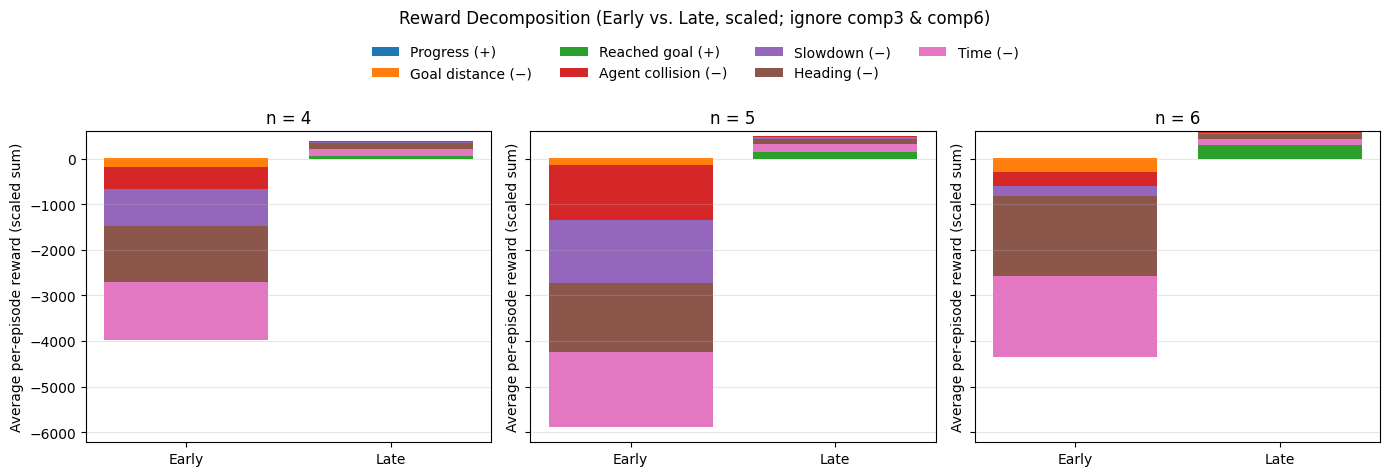

In [6]:
# Jupyter cell — Figure 9: Reward Decomposition (stacked bars, Early vs. Late) for n = 4, 5, 6
# Inputs: result4.csv, result5.csv, result6.csv
# What it shows:
#   • For each n, two stacked bars: EARLY episodes vs. LATE episodes.
#   • Each stack is the average per-episode contribution of each reward component (scaled).
# Scaling & ignoring (as requested):
#   • Multiply component k by scale = [1., 1., 0., 10., 10., 10., 1., 1., 1.]
#   • Ignore component 3 (base penalty)  -> scale[2] = 0
#   • Ignore component 6 (obstacle term) -> force scale[5] = 0 even if present in CSV
# Notes:
#   • Per-episode contribution for component k is Σ_t Σ_agents agent_i_compk[t] × scale[k].
#   • We then average these episode-level totals over EARLY or LATE episode sets.
# Output: figure9_reward_decomposition.png/.pdf

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Config ----------------
FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}
EARLY_EP = 100   # average over first EARLY_EP episodes
LATE_EP  = 100   # average over last  LATE_EP  episodes

OUT_PNG = "figure9_reward_decomposition.png"
OUT_PDF = "figure9_reward_decomposition.pdf"

# Reward component scale (comp1..comp9). Force-ignore comp3 and comp6.
reward_scale = np.array([1., 1., 0., 10., 10., 10., 1., 1., 1.], dtype=float)
reward_scale[2] = 0.0  # comp3 base penalty ignored
reward_scale[5] = 0.0  # comp6 obstacle penalty ignored (not present in your env)

# Human-readable labels for components (only those we keep will be shown)
COMP_LABELS = {
    1: "Progress (+)",
    2: "Goal distance (−)",
    3: "Base (ignored)",
    4: "Reached goal (+)",
    5: "Agent collision (−)",
    6: "Obstacle collision (ignored)",
    7: "Slowdown (−)",
    8: "Heading (−)",
    9: "Time (−)"
}

# ---------------- Helpers ----------------
comp_regex = re.compile(r"agent(\d+)_comp(\d+)$")

def infer_agents(df: pd.DataFrame) -> int:
    agents = set()
    for c in df.columns:
        m = comp_regex.match(c)
        if m:
            agents.add(int(m.group(1)))
    return (max(agents) + 1) if agents else 0

def list_comp_columns(df: pd.DataFrame, n_agents: int):
    """Return dict: k -> [col names for all agents for component k]."""
    by_k = {k: [] for k in range(1, 10)}
    for k in range(1, 10):
        for a in range(n_agents):
            col = f"agent{a}_comp{k}"
            if col in df.columns:
                by_k[k].append(col)
    return by_k

def episode_component_totals(df: pd.DataFrame, n_expected: int = None):
    """
    Compute per-episode totals for each component (1..9) after scaling & ignoring.
    Returns a DataFrame indexed by episode_id with columns comp1..comp9 (scaled sums).
    """
    if "episode_id" not in df.columns:
        raise ValueError("CSV missing 'episode_id'.")
    n_agents = infer_agents(df)
    if n_expected is not None and n_agents and (n_agents != n_expected):
        # proceed but warn by comment; we trust filename's n in plotting layout
        pass

    comp_cols_by_k = list_comp_columns(df, n_agents)
    # Sum per step across agents for each component k
    per_step_scaled = {}
    for k in range(1, 10):
        cols = comp_cols_by_k.get(k, [])
        if not cols:
            # If a component is absent, treat as zeros
            per_step_scaled[k] = np.zeros(len(df), dtype=float)
            continue
        # Sum across agents at each step
        raw_sum = df[cols].sum(axis=1).to_numpy()
        per_step_scaled[k] = reward_scale[k-1] * raw_sum  # apply scaling

    # Aggregate to episode totals (sum over steps)
    per_ep = pd.DataFrame({
        f"comp{k}": pd.Series(per_step_scaled[k])
    for k in range(1, 10)})
    per_ep["episode_id"] = df["episode_id"].values
    per_ep_tot = per_ep.groupby("episode_id", sort=True).sum()

    return per_ep_tot  # columns comp1..comp9

def pick_early_late_ids(df: pd.DataFrame, early_k: int, late_k: int):
    eps = np.array(sorted(df["episode_id"].unique()))
    early = eps[:min(early_k, len(eps))]
    late  = eps[-min(late_k, len(eps)):] if len(eps) > 0 else eps
    return early, late

# ---------------- Compute ----------------
# Build a tidy table with average component contributions for early/late per n
records = []

for n, path in FILES.items():
    if not os.path.exists(path):
        print(f"WARNING: '{path}' not found. Skipping n={n}.")
        continue
    df = pd.read_csv(path)

    df=df[df['episode_id']<=1000]
    if "episode_id" not in df.columns:
        raise ValueError(f"{path} missing 'episode_id' column.")

    early_ids, late_ids = pick_early_late_ids(df, EARLY_EP, LATE_EP)
    ep_totals = episode_component_totals(df, n_expected=n)  # per-episode comp totals (scaled)

    # Early mean (across selected episodes)
    early_mean = ep_totals.loc[early_ids].mean(axis=0, numeric_only=True)
    # Late mean
    late_mean  = ep_totals.loc[late_ids].mean(axis=0, numeric_only=True)

    # Store long-form records for components we actually keep (scale != 0)
    for k in range(1, 10):
        if reward_scale[k-1] == 0.0:
            continue  # ignored component
        records.append({"n": n, "phase": "Early", "comp": k, "value": early_mean.get(f"comp{k}", 0.0)})
        records.append({"n": n, "phase": "Late",  "comp": k, "value": late_mean.get(f"comp{k}", 0.0)})

if not records:
    raise SystemExit("No CSVs found. Place result4.csv, result5.csv, result6.csv next to this notebook and rerun.")

tidy = pd.DataFrame.from_records(records)
# Order components by their index (excluding ignored)
comp_order = [k for k in range(1, 10) if reward_scale[k-1] != 0.0]
phase_order = ["Early", "Late"]
n_list = sorted(tidy["n"].unique())

# ---------------- Plot ----------------
# One subplot per n; two bars (Early/Late) per subplot; stacks by component
fig, axes = plt.subplots(1, len(n_list), figsize=(14, 4), sharey=True)

if len(n_list) == 1:
    axes = [axes]

for ax, n in zip(axes, n_list):
    sub = tidy[tidy["n"] == n]
    # Build matrix: rows = phase (Early/Late), cols = components
    mat = np.array([
        [sub[(sub["phase"] == ph) & (sub["comp"] == k)]["value"].sum() for k in comp_order]
        for ph in phase_order
    ])  # shape (2, num_components)

    # Stacked bars
    x = np.arange(len(phase_order))
    bottoms = np.zeros(len(phase_order), dtype=float)
    for j, k in enumerate(comp_order):
        ax.bar(x, mat[:, j], bottom=bottoms, label=COMP_LABELS.get(k, f"comp{k}"))
        bottoms += mat[:, j]

    ax.set_xticks(x)
    ax.set_xticklabels(phase_order)
    ax.set_title(f"n = {n}")
    ax.set_ylabel("Average per-episode reward (scaled sum)")
    ax.grid(True, axis="y", alpha=0.3)

# Single legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(len(comp_order), 4), frameon=False, bbox_to_anchor=(0.5, 1.12))
fig.suptitle(f"Reward Decomposition (Early vs. Late, scaled; ignore comp3 & comp6)", y=1.18)
fig.tight_layout(rect=[0.0, 0.0, 1.0, 1.05])

plt.savefig(OUT_PNG, dpi=600, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")

print(f"Saved: {OUT_PNG}, {OUT_PDF}")

# Optional: print a compact table to paste into the paper, values per phase per n
pivot = tidy.pivot_table(index=["n", "phase"], columns="comp", values="value", aggfunc="sum").fillna(0.0)
# Keep only non-ignored comps in a nice order
pivot = pivot.reindex(columns=comp_order)
print("\nAverage per-episode component contributions (scaled):")
print(pivot.round(2))


Saved: figure10_collision_trend.png and figure10_collision_trend.pdf


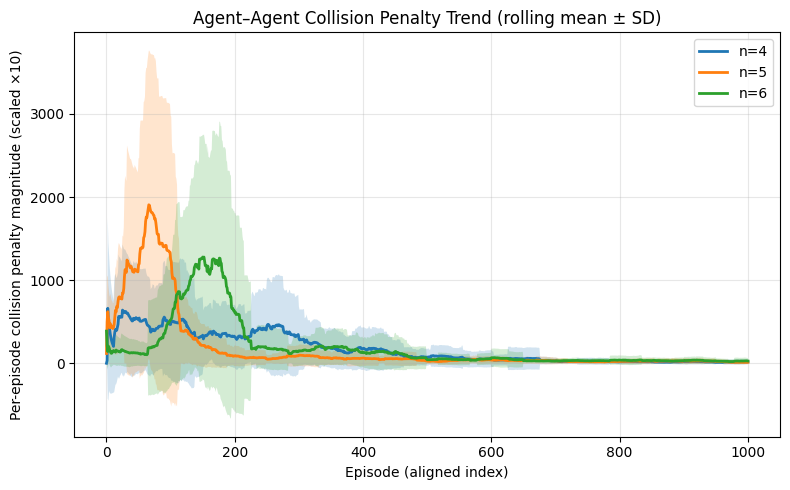

In [7]:
# Jupyter cell — Figure 10: Agent–Agent Collision Penalty Trend (n = 4, 5, 6)
# Inputs: result4.csv, result5.csv, result6.csv
# What it plots:
#   • For each n, the per-episode *magnitude* of agent–agent collision penalty, smoothed across episodes.
#   • Penalty is taken from component 5 only (agent–agent collisions), scaled by ×10.
#   • Component 6 (agent–obstacle) is ignored (no obstacles in your envs).
#   • Because penalties are negative in sign, we plot their positive magnitude:  magnitude = max(0, -sum_scaled_penalty_per_episode).
# Output: figure10_collision_trend.png/.pdf

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------- Config -------------
FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}
ROLLING_WINDOW = 50  # episodes for smoothing
OUT_PNG = "figure10_collision_trend.png"
OUT_PDF = "figure10_collision_trend.pdf"

# ------------- Helpers -------------
def infer_agent_count(df: pd.DataFrame) -> int:
    patt = re.compile(r"agent(\d+)_comp\d+")
    agents = set()
    for c in df.columns:
        m = patt.match(c)
        if m:
            agents.add(int(m.group(1)))
    return (max(agents) + 1) if agents else 0

def per_episode_collision_magnitude(df: pd.DataFrame, expected_n: int = None) -> pd.Series:
    """
    Returns a Series indexed by episode_id with the per-episode *magnitude* of
    agent–agent collision penalty (component 5), scaled by ×10 and summed over steps and agents.
    If penalties are negative, magnitude = -penalty_sum (clipped at 0).
    """
    if "episode_id" not in df.columns:
        raise ValueError("CSV must contain 'episode_id'.")

    n = infer_agent_count(df)
    if expected_n is not None and n and n != expected_n:
        # proceed regardless; we trust filename for labeling only
        pass

    # Collect all agent_i_comp5 columns present
    comp5_cols = [f"agent{i}_comp5" for i in range(n) if f"agent{i}_comp5" in df.columns]
    if not comp5_cols:
        # no explicit columns -> treat as zeros
        step_penalty_scaled = np.zeros(len(df), dtype=float)
    else:
        # sum across agents at each step, then scale by ×10 (agent–agent collision scale)
        raw = df[comp5_cols].sum(axis=1).to_numpy()
        step_penalty_scaled = 10.0 * raw

    # Sum across steps within each episode -> per-episode total (likely negative or zero)
    per_ep_pen = pd.Series(step_penalty_scaled, index=df.index)
    per_ep_pen.name = "collision_pen_scaled"
    per_ep_total = per_ep_pen.groupby(df["episode_id"]).sum()

    # Convert to positive magnitude for readability
    per_ep_mag = (-per_ep_total).clip(lower=0.0)
    per_ep_mag.name = "collision_penalty_magnitude"
    return per_ep_mag.sort_index()

# ------------- Load & compute -------------
series_by_n = {}
for n, path in FILES.items():
    if not os.path.exists(path):
        print(f"WARNING: '{path}' not found. Skipping n={n}.")
        continue
    df = pd.read_csv(path)
    df=df[df['episode_id'] <=1000]
    s = per_episode_collision_magnitude(df, expected_n=n)  # index: episode_id
    series_by_n[n] = s

if not series_by_n:
    raise SystemExit("No CSV files were found. Place result4.csv, result5.csv, result6.csv and rerun this cell.")

# Align episode indices across n (union)
all_eps = sorted(set().union(*[s.index.tolist() for s in series_by_n.values()]))
aligned = {n: s.reindex(all_eps) for n, s in series_by_n.items()}

# ------------- Plot -------------
plt.figure(figsize=(8, 5))

for n, s in sorted(aligned.items()):
    # Rolling mean and ±1 SD (across episodes within the window)
    rolling_mean = s.rolling(window=ROLLING_WINDOW, min_periods=1).mean()
    rolling_std  = s.rolling(window=ROLLING_WINDOW, min_periods=1).std().fillna(0.0)
    x = np.arange(len(rolling_mean))
    plt.plot(x, rolling_mean.values, linewidth=2.0, label=f"n={n}")
    plt.fill_between(x, (rolling_mean - rolling_std).values, (rolling_mean + rolling_std).values, alpha=0.2)

plt.xlabel("Episode (aligned index)")
plt.ylabel("Per-episode collision penalty magnitude (scaled ×10)")
plt.title("Agent–Agent Collision Penalty Trend (rolling mean ± SD)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=600, bbox_inches="tight")  # high-res raster for drafts
plt.savefig(OUT_PDF, bbox_inches="tight")          # vector for manuscript
print(f"Saved: {OUT_PNG} and {OUT_PDF}")

# Caption suggestion:
# "Per-episode magnitude of the agent–agent collision penalty (component 5), summed over all agents
# and timesteps, scaled by ×10. Solid lines show a rolling mean over {ROLLING_WINDOW} episodes; shaded
# regions indicate ±1 standard deviation. The agent–obstacle collision component is ignored (no obstacles)."


Saved: figure11_hungarian_distance_vs_timestep.png, figure11_hungarian_distance_vs_timestep.pdf


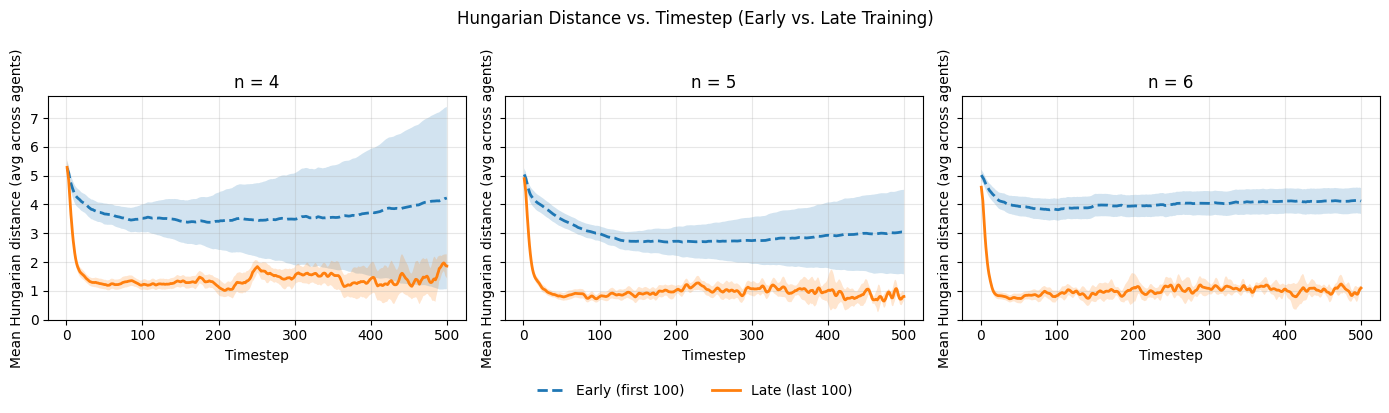

In [10]:
# Jupyter cell — Figure 11: Hungarian distance vs. timestep (Early vs. Late)
# Inputs: result4.csv, result5.csv, result6.csv
# What it shows:
#   For each team size n ∈ {4,5,6}, the mean Hungarian assignment distance (averaged across agents)
#   as a function of timestep. We compare the "Early" phase (first EARLY_EP episodes) and the "Late"
#   phase (last LATE_EP episodes). Shaded bands are 95% CIs of the mean across episodes available at
#   each timestep. (Episodes can have different lengths; the number of contributing episodes declines
#   at later timesteps.)
#
# Notes:
#   • Uses columns named hung_dist_agent0, hung_dist_agent1, …, hung_dist_agent{n-1}.
#   • No reward scaling is applied here—these are distances, not reward components.
#   • Optional smoothing along the timestep axis is provided for readability.

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Config ----------------
FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}

EARLY_EP = 100   # number of first episodes to average (per n)
LATE_EP  = 100   # number of last  episodes to average (per n)

SMOOTH_WINDOW = 5      # rolling window along timesteps for visual smoothing (set to 1 to disable)
Y_SHARE = True         # share the same y-axis across subplots
OUT_PNG = "figure11_hungarian_distance_vs_timestep.png"
OUT_PDF = "figure11_hungarian_distance_vs_timestep.pdf"

# -------------- Helpers -----------------
hung_regex = re.compile(r"hung_dist_agent(\d+)$")

def ensure_columns(df, path):
    if "episode_id" not in df.columns or "timestep" not in df.columns:
        raise ValueError(f"{path} must contain 'episode_id' and 'timestep' columns.")

def infer_agent_count_from_hung(df):
    idxs = []
    for c in df.columns:
        m = hung_regex.match(c)
        if m:
            idxs.append(int(m.group(1)))
    return (max(idxs) + 1) if idxs else 0

def hung_cols(df, n):
    return [f"hung_dist_agent{i}" for i in range(n) if f"hung_dist_agent{i}" in df.columns]

def pick_early_late_episode_ids(df, early_k, late_k):
    eps = np.array(sorted(df["episode_id"].unique()))
    early = eps[:min(early_k, len(eps))]
    late  = eps[-min(late_k, len(eps)):] if len(eps) > 0 else eps
    return early, late

def mean_curve_with_ci_over_episodes(df, n, episode_ids):
    """
    Build mean ± 95% CI curves across episodes at each timestep.
    Steps:
      1) Row-wise mean across agent Hungarian distances at each (episode, timestep).
      2) Group by timestep → mean, std, count across episodes.
      3) 95% CI of the mean: mean ± 1.96 * (std / sqrt(count)).
    Returns arrays (t, mean, lo, hi).
    """
    cols = hung_cols(df, n)
    if not cols:
        raise ValueError("No hung_dist_agent* columns found.")

    sub = df[df["episode_id"].isin(episode_ids)].copy()
    sub = sub.sort_values(["episode_id", "timestep"]).reset_index(drop=True)

    # Per-row mean across agents
    sub["hung_mean"] = sub[cols].mean(axis=1)

    # Aggregate across episodes at each timestep
    g = sub.groupby("timestep")["hung_mean"]
    mean = g.mean()
    std  = g.std(ddof=1)
    cnt  = g.count().clip(lower=1)
    sem  = std / np.sqrt(cnt)
    z = 1.96
    lo = (mean - z*sem).fillna(mean)
    hi = (mean + z*sem).fillna(mean)

    t = mean.index.to_numpy(dtype=int)
    return t, mean.to_numpy(), lo.to_numpy(), hi.to_numpy()

def smooth_series(y, w):
    if w <= 1:
        return y
    s = pd.Series(y, dtype=float)
    return s.rolling(window=w, min_periods=1, center=True).mean().to_numpy()

# -------------- Load & Plot -------------
ns = [n for n in [4,5,6] if os.path.exists(FILES.get(n, ""))]
if not ns:
    raise SystemExit("No CSV files found. Place result4.csv, result5.csv, result6.csv next to this notebook and rerun.")

fig, axes = plt.subplots(1, len(ns), figsize=(14, 4), sharey=Y_SHARE)
if len(ns) == 1:
    axes = [axes]

y_max_across = 0.0

for ax, n in zip(axes, ns):
    path = FILES[n]
    df = pd.read_csv(path)

    df=df[df['episode_id'] <=1000]
    ensure_columns(df, path)
    df = df.sort_values(["episode_id", "timestep"]).reset_index(drop=True)

    n_inferred = infer_agent_count_from_hung(df)
    if n_inferred and n_inferred != n:
        print(f"Note: inferred n={n_inferred} from columns in {path}; plotting as n={n} per filename.")

    early_ids, late_ids = pick_early_late_episode_ids(df, EARLY_EP, LATE_EP)

    # Early curve
    te, me, le, he = mean_curve_with_ci_over_episodes(df, n_inferred or n, early_ids)
    # Late curve
    tl, ml, ll, hl = mean_curve_with_ci_over_episodes(df, n_inferred or n, late_ids)

    # Optional smoothing along timesteps
    me_s, ml_s = smooth_series(me, SMOOTH_WINDOW), smooth_series(ml, SMOOTH_WINDOW)
    le_s, he_s = smooth_series(le, SMOOTH_WINDOW), smooth_series(he, SMOOTH_WINDOW)
    ll_s, hl_s = smooth_series(ll, SMOOTH_WINDOW), smooth_series(hl, SMOOTH_WINDOW)

    # Plot early (dashed) and late (solid)
    ax.plot(te, me_s, linestyle="--", linewidth=2, label=f"Early (first {len(early_ids)})")
    ax.fill_between(te, le_s, he_s, alpha=0.2)
    ax.plot(tl, ml_s, linestyle="-", linewidth=2, label=f"Late (last {len(late_ids)})")
    ax.fill_between(tl, ll_s, hl_s, alpha=0.2)

    ax.set_title(f"n = {n}")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Mean Hungarian distance (avg across agents)")
    ax.grid(True, alpha=0.3)

    y_max_across = max(y_max_across, np.nanmax([me_s.max() if len(me_s) else 0,
                                                ml_s.max() if len(ml_s) else 0,
                                                he_s.max() if len(he_s) else 0,
                                                hl_s.max() if len(hl_s) else 0]))

# Harmonize y-limits if sharing y
if Y_SHARE:
    for ax in axes:
        ax.set_ylim(bottom=0.0, top=y_max_across * 1.05 if y_max_across > 0 else 1.0)

# Legend below the panels, away from the title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Hungarian Distance vs. Timestep (Early vs. Late Training)", y=0.98)
fig.tight_layout(rect=[0.0, 0.06, 1.0, 0.94])

plt.savefig(OUT_PNG, dpi=600, bbox_inches="tight")   # high-res raster for drafts
plt.savefig(OUT_PDF, bbox_inches="tight")            # vector for the manuscript

print(f"Saved: {OUT_PNG}, {OUT_PDF}")

# Caption suggestion:
# "Mean Hungarian assignment distance per timestep, averaged across agents, comparing early (first {EARLY_EP})
# and late (last {LATE_EP}) training. Shaded regions show 95% confidence intervals of the mean across episodes
# available at each timestep. Curves reflect decreasing sample sizes at later timesteps due to different episode lengths."


Saved: figure12_velocity_profiles.png, figure12_velocity_profiles.pdf


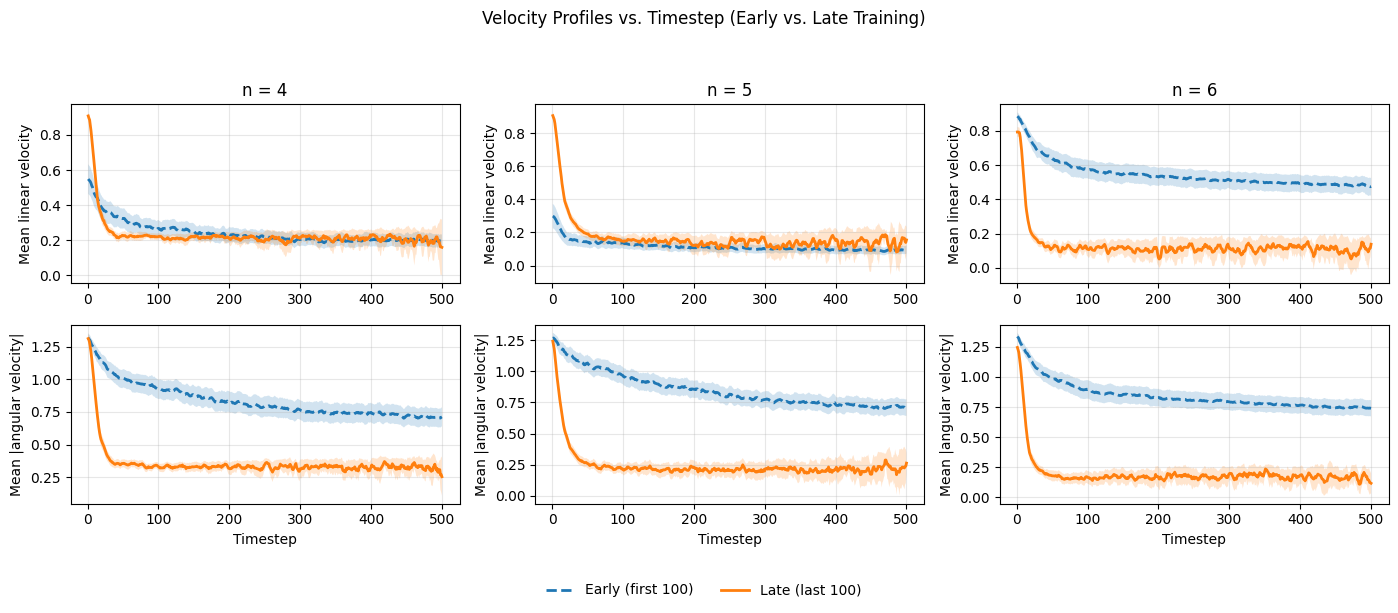

In [11]:
# Jupyter cell — Figure 12: Average linear & angular velocity profiles vs. timestep (Early vs. Late)
# Inputs: result4.csv, result5.csv, result6.csv
# What it plots:
#   • For each team size n ∈ {4,5,6}, two panels:
#       - Top row: mean linear velocity vs. timestep
#       - Bottom row: mean |angular| velocity vs. timestep (absolute value to reflect turning intensity)
#   • “Early” = first EARLY_EP episodes; “Late” = last LATE_EP episodes (per n).
#   • Curves are mean across episodes (and agents); bands are 95% CI of the mean across episodes
#     available at each timestep. Optional smoothing along the timestep axis is provided.
#
# Notes:
#   • Uses columns: agent{i}_vel_lin and agent{i}_vel_ang (i = 0..n-1).
#   • No reward scaling here—these are kinematic quantities.
#   • Optional normalization to fractions of vmax and omegamax.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Config ----------------
FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}

EARLY_EP = 100        # number of first episodes to average per n
LATE_EP  = 100        # number of last  episodes to average per n

SMOOTH_WINDOW = 5     # moving-average window across timesteps for readability (set to 1 to disable)
USE_ABS_ANG = True    # plot mean absolute angular velocity; set False to plot signed mean ω
NORMALIZE = False     # if True, divide v by VMAX and |ω| by OMEGAMAX
VMAX = 1.0            # set if NORMALIZE=True (from your env; Methods used vmax = 1)
OMEGAMAX = np.pi/2    # set if NORMALIZE=True (from your env; Methods used π/2)

OUT_PNG = "figure12_velocity_profiles.png"
OUT_PDF = "figure12_velocity_profiles.pdf"

# -------------- Helpers -----------------
def ensure_columns(df, path):
    if "episode_id" not in df.columns or "timestep" not in df.columns:
        raise ValueError(f"{path} must contain 'episode_id' and 'timestep' columns.")

def infer_agent_count(df):
    a_lin = [int(c.split("_")[0][5:]) for c in df.columns if c.startswith("agent") and c.endswith("_vel_lin")]
    a_ang = [int(c.split("_")[0][5:]) for c in df.columns if c.startswith("agent") and c.endswith("_vel_ang")]
    idxs = a_lin + a_ang
    return (max(idxs) + 1) if idxs else 0

def vel_columns(df, n):
    lin = [f"agent{i}_vel_lin" for i in range(n) if f"agent{i}_vel_lin" in df.columns]
    ang = [f"agent{i}_vel_ang" for i in range(n) if f"agent{i}_vel_ang" in df.columns]
    return lin, ang

def pick_early_late_episode_ids(df, early_k, late_k):
    eps = np.array(sorted(df["episode_id"].unique()))
    early = eps[:min(early_k, len(eps))]
    late  = eps[-min(late_k, len(eps)):] if len(eps) > 0 else eps
    return early, late

def mean_curve_ci(df, n, ep_ids, use_abs_ang=True, normalize=False, vmax=1.0, omegamax=np.pi/2):
    """
    Build mean ± 95% CI curves for linear velocity and (absolute) angular velocity across episodes.
    Steps:
      1) For each row (episode,timestep), average across agents to get a single v_lin and ω value.
      2) Group by timestep → mean, std, count across episodes.
      3) 95% CI of the mean: mean ± 1.96 * (std / sqrt(count)).
    Returns: (t, v_mean, v_lo, v_hi, w_mean, w_lo, w_hi)
    """
    lin_cols, ang_cols = vel_columns(df, n)
    if not lin_cols or not ang_cols:
        raise ValueError("Missing agent*_vel_lin or agent*_vel_ang columns.")

    sub = df[df["episode_id"].isin(ep_ids)].copy()
    sub = sub.sort_values(["episode_id", "timestep"]).reset_index(drop=True)

    # Per-row means across agents
    v_lin_row = sub[lin_cols].mean(axis=1)
    if use_abs_ang:
        w_ang_row = sub[ang_cols].abs().mean(axis=1)
    else:
        w_ang_row = sub[ang_cols].mean(axis=1)

    if normalize:
        if vmax is not None and vmax > 0:
            v_lin_row = v_lin_row / float(vmax)
        if omegamax is not None and omegamax > 0:
            w_ang_row = w_ang_row / float(omegamax)

    # Aggregate across episodes at each timestep
    def agg_ci(series):
        g = series.groupby(sub["timestep"])
        mean = g.mean()
        std  = g.std(ddof=1)
        cnt  = g.count().clip(lower=1)
        sem  = std / np.sqrt(cnt)
        z = 1.96
        lo  = (mean - z*sem).fillna(mean)
        hi  = (mean + z*sem).fillna(mean)
        return mean, lo, hi

    v_mean, v_lo, v_hi = agg_ci(v_lin_row)
    w_mean, w_lo, w_hi = agg_ci(w_ang_row)

    # Align and return
    t = v_mean.index.astype(int).to_numpy()
    return (
        t,
        v_mean.to_numpy(), v_lo.to_numpy(), v_hi.to_numpy(),
        w_mean.reindex(v_mean.index).to_numpy(),
        w_lo.reindex(v_mean.index).to_numpy(),
        w_hi.reindex(v_mean.index).to_numpy()
    )

def smooth(y, w):
    if w <= 1: return y
    s = pd.Series(y, dtype=float)
    return s.rolling(window=w, min_periods=1, center=True).mean().to_numpy()

# -------------- Load & Plot -------------
ns = [n for n in [4,5,6] if os.path.exists(FILES.get(n, ""))]
if not ns:
    raise SystemExit("No CSV files found. Place result4.csv, result5.csv, result6.csv next to this notebook and rerun.")

fig, axes = plt.subplots(2, len(ns), figsize=(14, 6), sharex=False, sharey=False)
if len(ns) == 1:
    axes = np.array([[axes[0]], [axes[1]]])  # ensure 2x1 array

for col_idx, n in enumerate(ns):
    path = FILES[n]
    df = pd.read_csv(path)

    df=df[df['episode_id'] <=1000]
    ensure_columns(df, path)
    df = df.sort_values(["episode_id", "timestep"]).reset_index(drop=True)

    n_inf = infer_agent_count(df) or n
    early_ids, late_ids = pick_early_late_episode_ids(df, EARLY_EP, LATE_EP)

    # Early curves
    te, v_me, v_le, v_he, w_me, w_le, w_he = mean_curve_ci(
        df, n_inf, early_ids, use_abs_ang=USE_ABS_ANG, normalize=NORMALIZE, vmax=VMAX, omegamax=OMEGAMAX
    )
    # Late curves
    tl, v_ml, v_ll, v_hl, w_ml, w_ll, w_hl = mean_curve_ci(
        df, n_inf, late_ids, use_abs_ang=USE_ABS_ANG, normalize=NORMALIZE, vmax=VMAX, omegamax=OMEGAMAX
    )

    # Smooth along timesteps if requested
    v_me, v_le, v_he = smooth(v_me, SMOOTH_WINDOW), smooth(v_le, SMOOTH_WINDOW), smooth(v_he, SMOOTH_WINDOW)
    v_ml, v_ll, v_hl = smooth(v_ml, SMOOTH_WINDOW), smooth(v_ll, SMOOTH_WINDOW), smooth(v_hl, SMOOTH_WINDOW)
    w_me, w_le, w_he = smooth(w_me, SMOOTH_WINDOW), smooth(w_le, SMOOTH_WINDOW), smooth(w_he, SMOOTH_WINDOW)
    w_ml, w_ll, w_hl = smooth(w_ml, SMOOTH_WINDOW), smooth(w_ll, SMOOTH_WINDOW), smooth(w_hl, SMOOTH_WINDOW)

    # ---------- Top row: linear velocity ----------
    ax_v = axes[0, col_idx]
    ax_v.plot(te, v_me, linestyle="--", linewidth=2, label=f"Early (first {len(early_ids)})")
    ax_v.fill_between(te, v_le, v_he, alpha=0.2)
    ax_v.plot(tl, v_ml, linestyle="-", linewidth=2, label=f"Late (last {len(late_ids)})")
    ax_v.fill_between(tl, v_ll, v_hl, alpha=0.2)
    ax_v.set_title(f"n = {n}")
    ax_v.set_ylabel("Mean linear velocity" + (" (fraction of vmax)" if NORMALIZE else ""))
    ax_v.grid(True, alpha=0.3)

    # ---------- Bottom row: angular velocity (|ω| by default) ----------
    ax_w = axes[1, col_idx]
    ax_w.plot(te, w_me, linestyle="--", linewidth=2)
    ax_w.fill_between(te, w_le, w_he, alpha=0.2)
    ax_w.plot(tl, w_ml, linestyle="-", linewidth=2)
    ax_w.fill_between(tl, w_ll, w_hl, alpha=0.2)
    ax_w.set_xlabel("Timestep")
    ang_label = "Mean |angular velocity|" if USE_ABS_ANG else "Mean angular velocity"
    ax_w.set_ylabel(ang_label + (" (fraction of ωmax)" if NORMALIZE else ""))
    ax_w.grid(True, alpha=0.3)

# One legend for all panels, placed below
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Velocity Profiles vs. Timestep (Early vs. Late Training)", y=0.98)
fig.tight_layout(rect=[0.0, 0.06, 1.0, 0.94])

plt.savefig(OUT_PNG, dpi=600, bbox_inches="tight")   # high-res raster for drafts
plt.savefig(OUT_PDF, bbox_inches="tight")            # vector for manuscript

print(f"Saved: {OUT_PNG}, {OUT_PDF}")

# Caption suggestion:
# "Mean linear velocity (top) and mean absolute angular velocity (bottom) as functions of timestep,
# comparing early (first {EARLY_EP}) and late (last {LATE_EP}) training for each team size.
# Curves show the mean across episodes (and agents); shaded regions denote 95% confidence intervals
# of the mean across episodes. Optional smoothing with a {SMOOTH_WINDOW}-step moving average is applied."


In [12]:
# Jupyter cell — Table 2: Final summary across n = 4, 5, 6
# Metrics (computed per team size n and then averaged over the final LAST_EPISODES episodes):
#   • success_rate: fraction of episodes where all n agents reached goals (max(done_count) == n)
#   • avg_completion_time_steps: mean timestep of first all-done event (successful episodes only)
#   • avg_return: mean per-episode cumulative reward (sum over time and agents of scaled components)
#
# Reward scaling (comp1..comp9) applied to each agent’s components at every step:
#   scale = [1., 1., 0., 10., 10., 10., 1., 1., 1.]
#   (comp3 is ignored via 0; comp6 (obstacle) effectively ignored; comp5 includes ×10)
#
# Inputs: result4.csv, result5.csv, result6.csv
# Output: prints summary DataFrame and saves to 'table2_summary.csv'

import os
import re
import numpy as np
import pandas as pd

# -------- Config --------
FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}
LAST_EPISODES = 200   # use the last K episodes for "final" summary; set to None to use all episodes
OUT_CSV = "table2_summary.csv"

# Reward component scale (comp1..comp9)
REWARD_SCALE = np.array([1., 1., 0., 10., 10., 10., 1., 1., 1.], dtype=float)
# (comp3 base penalty ignored by 0; comp6 obstacle penalty is absent/ignored; comp5 already ×10)

# -------- Helpers --------
COMP_COL_RE = re.compile(r"agent(\d+)_comp(\d+)$")

def infer_agent_count(df: pd.DataFrame) -> int:
    agents = set()
    for c in df.columns:
        m = COMP_COL_RE.match(c)
        if m:
            agents.add(int(m.group(1)))
    return (max(agents) + 1) if agents else 0

def select_last_episodes(df: pd.DataFrame, k: int | None) -> pd.DataFrame:
    if k is None:
        return df
    eps = np.array(sorted(df["episode_id"].unique()))
    keep = eps[-min(k, len(eps)):]
    return df[df["episode_id"].isin(keep)]

def compute_episode_returns(df: pd.DataFrame, expected_n: int | None = None) -> pd.Series:
    """
    Per-episode cumulative reward using scaled reward components (comp1..comp9) summed over agents and timesteps.
    Returns a Series indexed by episode_id.
    """
    if "episode_id" not in df.columns:
        raise ValueError("CSV must contain 'episode_id'.")

    n = infer_agent_count(df)
    if expected_n is not None and n and n != expected_n:
        # Proceed anyway; just a heads-up in print if you wish
        pass

    # Build per-step total reward
    step_total = np.zeros(len(df), dtype=float)
    for agent_idx in range(n):
        # Collect this agent's 9 components (comp1..comp9); default to 0 if missing
        comps = []
        for k in range(1, 10):
            col = f"agent{agent_idx}_comp{k}"
            if col in df.columns:
                comps.append(df[col].to_numpy(dtype=float))
            else:
                comps.append(np.zeros(len(df), dtype=float))
        comps = np.vstack(comps)  # shape (9, steps)
        step_total += (REWARD_SCALE[:, None] * comps).sum(axis=0)

    # Sum per episode
    ep_returns = pd.Series(step_total, index=df.index)
    return ep_returns.groupby(df["episode_id"]).sum().sort_index()

def per_episode_success_and_completion(df: pd.DataFrame, n: int) -> pd.DataFrame:
    """
    Compute per-episode:
      - success: 1 if max(done_count) == n (all agents reached goals), else 0.
      - completion_time: first timestep where done_count == n (NaN if never).
    Returns DataFrame with index=episode_id and columns ['success', 'completion_time'].
    """
    required = {"episode_id", "timestep", "done_count"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV missing columns: {sorted(missing)}")

    df = df.sort_values(["episode_id", "timestep"]).reset_index(drop=True)
    grp = df.groupby("episode_id", sort=True)

    # success flag per episode
    success = (grp["done_count"].max() >= n).astype(int)

    # first timestep where all agents are done
    def first_all_done(g: pd.DataFrame) -> float:
        idx = g.index[g["done_count"] >= n]
        if len(idx) == 0:
            return np.nan
        return float(g.loc[idx[0], "timestep"])

    completion = grp.apply(first_all_done)

    out = pd.DataFrame({"success": success, "completion_time": completion})
    out.index.name = "episode_id"
    return out

def summarize_for_file(path: str, n: int) -> dict:
    """
    Compute summary metrics for a single file/team-size n over the final LAST_EPISODES episodes.
    Returns dict with fields used in the final summary table.
    """
    df = pd.read_csv(path)
    df=df[df['episode_id'] <=1000]
    if "episode_id" not in df.columns:
        raise ValueError(f"{path} missing 'episode_id'.")

    # Restrict to last episodes for "final" summary
    df_final = select_last_episodes(df, LAST_EPISODES)

    # Per-episode totals/flags on this subset
    ep_return = compute_episode_returns(df_final, expected_n=n)
    sc = per_episode_success_and_completion(df_final, n)

    # Align indices (in case one calculation dropped some episodes)
    all_eps = sorted(set(ep_return.index).union(sc.index))
    ep_return = ep_return.reindex(all_eps)
    sc = sc.reindex(all_eps)

    # Metrics
    total_eps = len(all_eps)
    successes = int(sc["success"].sum(skipna=True))
    success_rate = successes / total_eps if total_eps > 0 else float("nan")

    comp_times = sc.loc[sc["success"] == 1, "completion_time"].astype(float)
    avg_comp = comp_times.mean() if len(comp_times) else float("nan")
    std_comp = comp_times.std(ddof=1) if len(comp_times) > 1 else float("nan")

    avg_ret = ep_return.mean() if len(ep_return) else float("nan")
    std_ret = ep_return.std(ddof=1) if len(ep_return) > 1 else float("nan")

    return {
        "n": n,
        "episodes_considered": total_eps,
        "successes": successes,
        "success_rate": success_rate,
        "avg_completion_time_steps": avg_comp,
        "completion_time_std": std_comp,
        "avg_return": avg_ret,
        "return_std": std_ret,
    }

# -------- Compute & Save --------
rows = []
for n, path in FILES.items():
    if not os.path.exists(path):
        print(f"WARNING: '{path}' not found. Skipping n={n}.")
        continue
    rows.append(summarize_for_file(path, n))

if not rows:
    raise SystemExit("No CSV files were found. Place result4.csv, result5.csv, result6.csv next to this notebook and rerun.")

summary = pd.DataFrame(rows).set_index("n").sort_index()

# Nice rounding for display (keep more precision in the CSV if you prefer)
display_cols = [
    "episodes_considered", "successes", "success_rate",
    "avg_completion_time_steps", "completion_time_std",
    "avg_return", "return_std"
]
summary_rounded = summary.copy()
summary_rounded["success_rate"] = summary_rounded["success_rate"].round(3)
summary_rounded["avg_completion_time_steps"] = summary_rounded["avg_completion_time_steps"].round(1)
summary_rounded["completion_time_std"] = summary_rounded["completion_time_std"].round(1)
summary_rounded["avg_return"] = summary_rounded["avg_return"].round(1)
summary_rounded["return_std"] = summary_rounded["return_std"].round(1)

print("Table 2 — Final summary (last {} episodes per n)".format(LAST_EPISODES if LAST_EPISODES is not None else "ALL"))
print(summary_rounded[display_cols])

# Save the unrounded DataFrame for precise values
summary.to_csv(OUT_CSV, index=True)
print(f"\nSaved full-precision table to: {OUT_CSV}")

# Caption suggestion for the paper (adapt as needed):
# "Final performance summary over the last {LAST_EPISODES} episodes for each team size n.
# Success rate counts episodes where all n agents reached their assigned landmarks (i.e., max(done_count) == n).
# Completion time averages are computed over successful episodes only.
# Episode returns are the sum over timesteps and agents of the scaled reward components:
# scale = [1, 1, 0, 10, 10, 10, 1, 1, 1] (base and obstacle components ignored; collision component ×10)."


C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\3390007029.py:102: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  completion = grp.apply(first_all_done)
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\3390007029.py:102: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  completion = grp.apply(first_all_done)


Table 2 — Final summary (last 200 episodes per n)
   episodes_considered  successes  success_rate  avg_completion_time_steps  \
n                                                                            
4                  200        187         0.935                       97.3   
5                  200        193         0.965                       89.2   
6                  200        194         0.970                       58.3   

   completion_time_std  avg_return  return_std  
n                                               
4                 94.4       -39.0       461.5  
5                 82.2        27.9       480.1  
6                 60.2       219.1       406.7  

Saved full-precision table to: table2_summary.csv


C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\3390007029.py:102: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  completion = grp.apply(first_all_done)


Saved: figure13_success_vs_n.png, figure13_success_vs_n.pdf


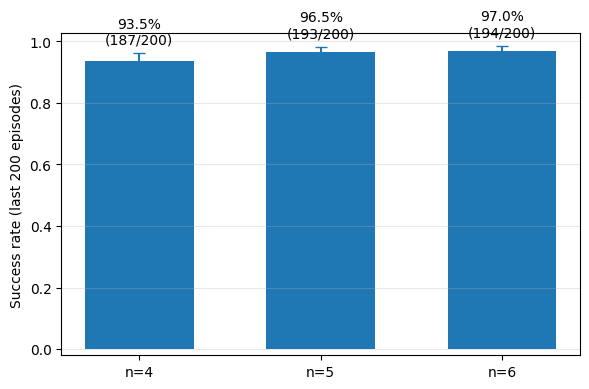

In [14]:
# Jupyter cell — Figure 13 (clean layout, no overlay):
# Success rate vs. team size with 95% Wilson CI and safe annotation placement.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Config ----------------
FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}
LAST_EPISODES = 200
CONF_LEVEL = 0.95
AS_BARS = True            # bar chart (True) or point+line (False)
TITLE = "Success Rate vs. Team Size (with 95% Wilson CI)"
TITLE_PAD = 12            # extra space above axes for the title
ANNOTATION_OFFSET = 0.02  # vertical gap between error bar tip and text
MAX_Y_TOP = 1.20          # never expand ylim beyond this
PNG = "figure13_success_vs_n.png"
PDF = "figure13_success_vs_n.pdf"

# -------------- Helpers -----------------
def need_cols(df, path, cols):
    miss = set(cols) - set(df.columns)
    if miss:
        raise ValueError(f"{path} missing columns: {sorted(miss)}")

def last_k_episode_ids(df: pd.DataFrame, k: int | None):
    eps = np.array(sorted(df["episode_id"].unique()))
    return eps if k is None or len(eps) <= k else eps[-k:]

def per_episode_success(df: pd.DataFrame, n: int) -> pd.Series:
    # success iff max(done_count) == n at any step
    gmax = df.groupby("episode_id", sort=True)["done_count"].max()
    return (gmax >= n).astype(int)

def wilson_ci(k: int, n: int, conf: float = 0.95):
    if n <= 0:
        return (np.nan, np.nan, np.nan)
    # 1.96 for 95% without SciPy
    z = 1.96 if abs(conf - 0.95) < 1e-9 else 1.96
    p = k / n
    denom = 1 + (z*z)/n
    center = p + (z*z)/(2*n)
    margin = z * np.sqrt((p*(1 - p) + (z*z)/(4*n)) / n)
    lo = (center - margin) / denom
    hi = (center + margin) / denom
    return (p, max(0.0, lo), min(1.0, hi))

# -------------- Compute -----------------
rows = []
for n, path in FILES.items():
    if not os.path.exists(path):
        print(f"WARNING: '{path}' not found. Skipping n={n}.")
        continue
    df = pd.read_csv(path)
    df=df[df['episode_id'] <=1000]
    need_cols(df, path, ["episode_id", "timestep", "done_count"])
    keep = last_k_episode_ids(df, LAST_EPISODES)
    dff = df[df["episode_id"].isin(keep)].copy()

    s = per_episode_success(dff, n)
    N = int(s.shape[0])
    K = int(s.sum())
    p, lo, hi = wilson_ci(K, N, conf=CONF_LEVEL)
    rows.append({"n": n, "episodes": N, "successes": K, "p": p, "lo": lo, "hi": hi})

if not rows:
    raise SystemExit("No CSVs found. Place result4.csv, result5.csv, result6.csv and rerun.")

tbl = pd.DataFrame(rows).sort_values("n").reset_index(drop=True)

# -------------- Plot (with safe headroom) ----------------
fig, ax = plt.subplots(figsize=(6, 4))

x = np.arange(len(tbl))
y = tbl["p"].to_numpy()
# yerr_up/down for error bars
yerr = np.vstack([y - tbl["lo"].to_numpy(), tbl["hi"].to_numpy() - y])

if AS_BARS:
    ax.bar(x, y, width=0.6)
    ax.errorbar(x, y, yerr=yerr, fmt="none", capsize=4, linewidth=1.5)
else:
    ax.plot(x, y, marker="o", linewidth=2)
    ax.errorbar(x, y, yerr=yerr, fmt="none", capsize=4, linewidth=1.5)

# --- Dynamic headroom above the tallest error bar ---
tops = y + yerr[1] + ANNOTATION_OFFSET
y_top = min(MAX_Y_TOP, max(1.02, tops.max() + ANNOTATION_OFFSET))
ax.set_ylim(-0.02, y_top)

# Annotations placed just above the error bars, clamped below the top
for xi, yi, N, K, up in zip(x, y, tbl["episodes"], tbl["successes"], yerr[1]):
    y_text = min(yi + up + ANNOTATION_OFFSET, y_top - ANNOTATION_OFFSET)
    ax.text(xi, y_text, f"{yi*100:.1f}%\n({K}/{N})", ha="center", va="bottom")

ax.set_xticks(x)
ax.set_xticklabels([f"n={n}" for n in tbl["n"]])
ax.set_ylabel(f"Success rate (last {LAST_EPISODES} episodes)")
# ax.set_title(TITLE, pad=TITLE_PAD)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(PNG, dpi=600, bbox_inches="tight")
fig.savefig(PDF, bbox_inches="tight")
print(f"Saved: {PNG}, {PDF}")


C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\4159630063.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ctime = g.apply(first_done)
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\4159630063.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ctime = g.apply(first_done)
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\4159630063.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the


Kruskal–Wallis (episode return, last 200 episodes)
  H = 108.827, p = 2.336132943178452e-24
Kruskal–Wallis (completion time, successful eps, last 200 episodes)
  H = 40.985, p = 1.2594024845484438e-09

Pairwise Mann–Whitney (episode return), Holm-adjusted p-values:
  n=4 vs n=5: p_adj = 0.002055
  n=4 vs n=6: p_adj = 6.282e-22
  n=5 vs n=6: p_adj = 2.947e-14

Pairwise Mann–Whitney (completion time, successful eps), Holm-adjusted p-values:
  n=4 vs n=5: p_adj = 0.9282
  n=4 vs n=6: p_adj = 1.307e-06
  n=5 vs n=6: p_adj = 4.24e-09

Saved: figureA_kw_mwu.png/.pdf


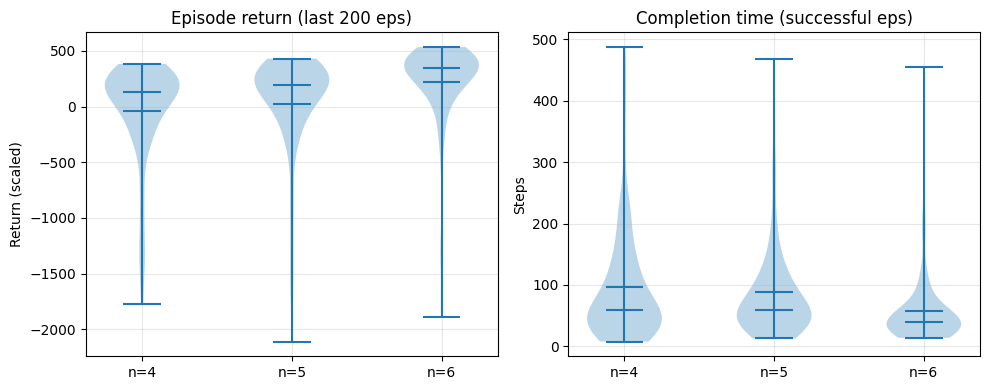

In [19]:
# Jupyter cell A — Nonparametric tests across n (Kruskal–Wallis + pairwise Mann–Whitney)
# Inputs: result4.csv, result5.csv, result6.csv
# Uses the LAST_EPISODES episodes per n.
# Metrics:
#   • completion_time (successful episodes only): first timestep where done_count == n
#   • episode_return (all episodes): sum over steps & agents of scaled reward components
# Reward scaling comp1..comp9: [1, 1, 0, 10, 10, 10, 1, 1, 1]  (comp3 ignored; comp6 absent/ignored)

import os, re, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If SciPy is available, we'll use it for exact p-values; otherwise we fall back to numpy approximations.
try:
    from scipy.stats import kruskal, mannwhitneyu
    from scipy.stats import rankdata, chi2
    SCIPY = True
except Exception:
    from math import sqrt, erfc
    SCIPY = False

FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}
LAST_EPISODES = 200   # set None to use ALL episodes

REWARD_SCALE = np.array([1., 1., 0., 10., 10., 10., 1., 1., 1.], dtype=float)

COMP_RE = re.compile(r"agent(\d+)_comp(\d+)$")

def last_k(df, k):
    if k is None: return df
    eps = np.array(sorted(df["episode_id"].unique()))
    keep = eps[-min(k, len(eps)):]
    return df[df["episode_id"].isin(keep)]

def infer_n_agents(df):
    ids = []
    for c in df.columns:
        m = COMP_RE.match(c)
        if m: ids.append(int(m.group(1)))
    return (max(ids) + 1) if ids else 0

def per_episode_return(df, expected_n=None):
    n = infer_n_agents(df)
    if expected_n and n and n != expected_n:
        pass  # keep going
    step_total = np.zeros(len(df), dtype=float)
    for i in range(n):
        comps = []
        for k in range(1,10):
            col = f"agent{i}_comp{k}"
            if col in df.columns:
                comps.append(df[col].to_numpy(float))
            else:
                comps.append(np.zeros(len(df)))
        comps = np.vstack(comps)  # (9, steps)
        step_total += (REWARD_SCALE[:, None] * comps).sum(axis=0)
    s = pd.Series(step_total, index=df.index)
    return s.groupby(df["episode_id"]).sum().sort_index()

def success_and_completion(df, n):
    need = {"episode_id","timestep","done_count"}
    if not need.issubset(df.columns):
        miss = sorted(list(need - set(df.columns)))
        raise ValueError(f"CSV missing columns: {miss}")
    df = df.sort_values(["episode_id","timestep"]).reset_index(drop=True)
    g = df.groupby("episode_id", sort=True)
    success = (g["done_count"].max() >= n).astype(int)
    def first_done(gr):
        idx = gr.index[gr["done_count"] >= n]
        return np.nan if len(idx)==0 else float(gr.loc[idx[0],"timestep"])
    ctime = g.apply(first_done)
    return pd.DataFrame({"success": success, "completion_time": ctime})

def holm_correction(pvals_by_pair):
    """Holm–Bonferroni correction for a dict {(a,b): p} -> dict with adjusted p."""
    items = sorted(pvals_by_pair.items(), key=lambda kv: kv[1])
    m = len(items)
    adj = {}
    for i, ((a,b), p) in enumerate(items, start=1):
        adj_p = min(1.0, p*(m - i + 1))
        adj[(a,b)] = adj_p
    # ensure monotonicity (optional)
    return adj

# --------- Gather per-n arrays ---------
returns = {}
comp_times = {}
for n, path in FILES.items():
    if not os.path.exists(path):
        print(f"WARNING: {path} not found; skipping n={n}")
        continue
    df = pd.read_csv(path)
    df=df[df['episode_id'] <=1000]
    df_final = last_k(df, LAST_EPISODES)

    ret = per_episode_return(df_final, expected_n=n)
    sc = success_and_completion(df_final, n)

    # align
    ep_idx = sorted(set(ret.index).union(sc.index))
    ret = ret.reindex(ep_idx)
    sc = sc.reindex(ep_idx)

    # arrays
    returns[n] = ret.dropna().to_numpy()
    comp_times[n] = sc.loc[sc["success"]==1, "completion_time"].dropna().to_numpy()

# --------- Kruskal–Wallis tests ---------
def kw_test(groups):
    if SCIPY:
        return kruskal(*groups, nan_policy="omit")
    # Fallback Kruskal implementation
    all_vals = np.concatenate(groups)
    ranks = rankdata(all_vals)  # average ranks for ties
    start = 0
    N = len(all_vals)
    H_num = 0.0
    for g in groups:
        ng = len(g)
        rg = ranks[start:start+ng].mean()
        start += ng
        H_num += ng * (rg - (N+1)/2.0)**2
    H = (12.0 / (N*(N+1))) * H_num
    df = len(groups) - 1
    # Without SciPy we won't compute exact p; print H only.
    return type("KW", (), {"statistic": H, "pvalue": np.nan, "df": df})

kw_ret = kw_test([v for v in returns.values() if len(v)>0])
kw_ct  = kw_test([v for v in comp_times.values() if len(v)>0])

print("\nKruskal–Wallis (episode return, last {} episodes)".format(LAST_EPISODES))
print(f"  H = {kw_ret.statistic:.3f}, p = {kw_ret.pvalue if kw_ret.pvalue==kw_ret.pvalue else 'requires SciPy'}")

print("Kruskal–Wallis (completion time, successful eps, last {} episodes)".format(LAST_EPISODES))
print(f"  H = {kw_ct.statistic:.3f}, p = {kw_ct.pvalue if kw_ct.pvalue==kw_ct.pvalue else 'requires SciPy'}")

# --------- Pairwise Mann–Whitney + Holm ---------
pairs = list(itertools.combinations(sorted(returns.keys()), 2))
pvals_ret = {}
pvals_ct  = {}

for a,b in pairs:
    if SCIPY:
        ua = mannwhitneyu(returns[a], returns[b], alternative="two-sided")
        pvals_ret[(a,b)] = ua.pvalue
        # completion time only if both have successes
        if len(comp_times[a])>0 and len(comp_times[b])>0:
            ub = mannwhitneyu(comp_times[a], comp_times[b], alternative="two-sided")
            pvals_ct[(a,b)] = ub.pvalue
        else:
            pvals_ct[(a,b)] = np.nan
    else:
        # Simple normal approx (fallback)
        def mwu(x,y):
            r = rankdata(np.concatenate([x,y]))
            nx, ny = len(x), len(y)
            U = r[:nx].sum() - nx*(nx+1)/2
            mu = nx*ny/2
            sigma = sqrt(nx*ny*(nx+ny+1)/12)
            z = (U - mu)/sigma if sigma>0 else 0.0
            # two-sided p approx via error function
            p = erfc(abs(z)/np.sqrt(2))
            return U, p
        _, pvals_ret[(a,b)] = mwu(returns[a], returns[b])
        if len(comp_times[a])>0 and len(comp_times[b])>0:
            _, pvals_ct[(a,b)] = mwu(comp_times[a], comp_times[b])
        else:
            pvals_ct[(a,b)] = np.nan

adj_ret = holm_correction({k:v for k,v in pvals_ret.items() if v==v})
adj_ct  = holm_correction({k:v for k,v in pvals_ct.items() if v==v})

print("\nPairwise Mann–Whitney (episode return), Holm-adjusted p-values:")
for (a,b), p in sorted(adj_ret.items()):
    print(f"  n={a} vs n={b}: p_adj = {p:.4g}")

print("\nPairwise Mann–Whitney (completion time, successful eps), Holm-adjusted p-values:")
for (a,b), p in sorted(adj_ct.items()):
    print(f"  n={a} vs n={b}: p_adj = {p:.4g}")

# --------- Quick violins for both metrics (optional) ---------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
# returns
labs = [f"n={n}" for n in sorted(returns)]
ax1.violinplot([returns[n] for n in sorted(returns)], showmeans=True, showmedians=True)
ax1.set_xticks(range(1, len(returns)+1), labs)
ax1.set_title("Episode return (last {} eps)".format(LAST_EPISODES))
ax1.set_ylabel("Return (scaled)")
ax1.grid(True, alpha=0.3)
# completion time
labs_ct = [f"n={n}" for n in sorted(comp_times)]
ax2.violinplot([comp_times[n] for n in sorted(comp_times)], showmeans=True, showmedians=True)
ax2.set_xticks(range(1, len(comp_times)+1), labs_ct)
ax2.set_title("Completion time (successful eps)")
ax2.set_ylabel("Steps")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figureA_kw_mwu.png", dpi=600, bbox_inches="tight")
plt.savefig("figureA_kw_mwu.pdf", bbox_inches="tight")
print("\nSaved: figureA_kw_mwu.png/.pdf")


C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\1762506391.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  t_event = g.apply(first_done).astype(float)
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\1762506391.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  t_event = g.apply(first_done).astype(float)
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\1762506391.py:39: DeprecationWarning: DataFr

Saved: figureB_km_logrank.png, figureB_km_logrank.pdf

Pairwise log-rank tests (χ², p):
  n=4 vs n=5: chi2 = 2.238, p = 0.13462366998637154
  n=4 vs n=6: chi2 = 26.621, p = 2.475516239774933e-07
  n=5 vs n=6: chi2 = 19.973, p = 7.856146008733411e-06


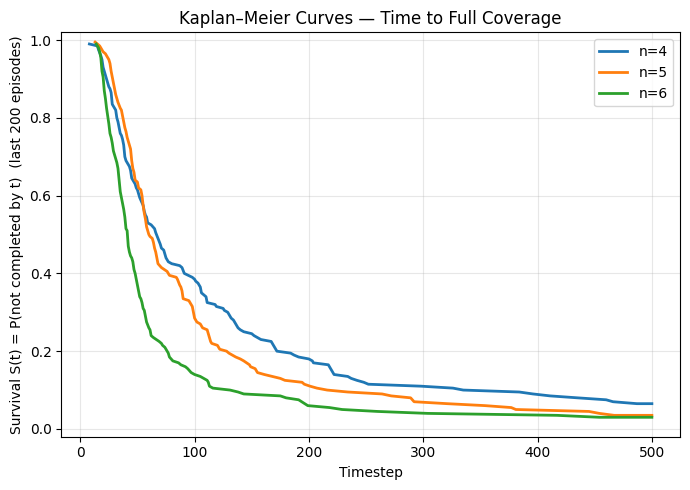

In [20]:
# Jupyter cell B — Kaplan–Meier curves + pairwise log-rank tests (time-to-completion)
# Inputs: result4.csv, result5.csv, result6.csv
# Treat first timestep with done_count == n as the event time; if never achieved, right-censor at the episode’s max timestep.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import chi2
    SCIPY = True
except Exception:
    SCIPY = False

FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}
LAST_EPISODES = 200
OUT_PNG = "figureB_km_logrank.png"
OUT_PDF = "figureB_km_logrank.pdf"

def last_k(df, k):
    if k is None: return df
    eps = np.array(sorted(df["episode_id"].unique()))
    keep = eps[-min(k, len(eps)):]
    return df[df["episode_id"].isin(keep)]

def event_censor_from_df(df, n):
    need = {"episode_id","timestep","done_count"}
    if not need.issubset(df.columns):
        missing = sorted(list(need - set(df.columns)))
        raise ValueError(f"Missing columns: {missing}")
    df = df.sort_values(["episode_id","timestep"]).reset_index(drop=True)
    g = df.groupby("episode_id", sort=True)

    # event time = first timestep with done_count == n, else NaN
    def first_done(gr):
        idx = gr.index[gr["done_count"] >= n]
        return np.nan if len(idx)==0 else float(gr.loc[idx[0], "timestep"])
    t_event = g.apply(first_done).astype(float)

    # censor time = last timestep observed in the episode
    t_last = g["timestep"].max().astype(float)
    # finalize vectors
    time = np.where(np.isnan(t_event), t_last.to_numpy(), t_event.to_numpy())
    event = (~np.isnan(t_event)).astype(int)
    return time, event

def km_curve(times, events):
    # Kaplan–Meier survival S(t) = Π (1 - d_i / r_i) over event times
    # Build table of unique times
    df = pd.DataFrame({"time": times, "event": events}).sort_values("time")
    uniq = np.unique(df["time"])
    at_risk = len(df)
    S = []
    t_out = []
    s_val = 1.0
    for t in uniq:
        d_i = int(((df["time"]==t) & (df["event"]==1)).sum())
        # number censored at t (do not contribute to d_i)
        c_i = int(((df["time"]==t) & (df["event"]==0)).sum())
        if at_risk > 0:
            if d_i > 0:
                s_val *= (1.0 - d_i/at_risk)
            S.append(s_val)
            t_out.append(t)
            # update risk set after accounting events & censoring at t
            at_risk -= (d_i + c_i)
    return np.array(t_out), np.array(S)

def logrank_pair(times1, events1, times2, events2):
    # Mantel–Haenszel log-rank test (1 df). Requires SciPy for p-value; returns (chi2, p)
    # Pool unique event times
    T = np.unique(np.concatenate([times1, times2]))
    # Build risk & events at each time for each group
    def risk_events(times, events, t):
        at_risk = np.sum(times >= t)
        d = np.sum((times == t) & (events == 1))
        return at_risk, d
    O1 = E1 = V1 = 0.0
    for t in T:
        n1, d1 = risk_events(times1, events1, t)
        n2, d2 = risk_events(times2, events2, t)
        n = n1 + n2
        d = d1 + d2
        if n == 0 or n1 == 0 or n2 == 0:
            continue
        e1 = d * (n1 / n)
        var = (n1 * n2 * d * (n - d)) / (n**2 * (n - 1)) if n > 1 else 0.0
        O1 += d1
        E1 += e1
        V1 += var
    z2 = (O1 - E1)**2 / V1 if V1 > 0 else 0.0
    p = (1.0 - chi2.cdf(z2, 1)) if SCIPY else np.nan
    return z2, p

# --------- Compute per-n curves and tests ---------
km_data = {}
pair_tests = {}
for n, path in FILES.items():
    if not os.path.exists(path):
        print(f"WARNING: {path} missing; skipping n={n}")
        continue
    df = pd.read_csv(path)
    df=df[df['episode_id'] <=1000]
    df = last_k(df, LAST_EPISODES)
    times, events = event_censor_from_df(df, n)
    # Sort by time (not strictly needed)
    km_t, km_s = km_curve(times, events)
    km_data[n] = {"t": km_t, "S": km_s, "times": times, "events": events}

# pairwise log-rank
ns = sorted(km_data.keys())
for i in range(len(ns)):
    for j in range(i+1, len(ns)):
        a, b = ns[i], ns[j]
        chi2_stat, p = logrank_pair(km_data[a]["times"], km_data[a]["events"],
                                    km_data[b]["times"], km_data[b]["events"])
        pair_tests[(a,b)] = (chi2_stat, p)

# --------- Plot ---------
plt.figure(figsize=(7,5))
for n in ns:
    plt.plot(km_data[n]["t"], km_data[n]["S"], label=f"n={n}", linewidth=2)
plt.ylim(-0.02, 1.02)
plt.xlabel("Timestep")
plt.ylabel(f"Survival S(t) = P(not completed by t)  (last {LAST_EPISODES} episodes)")
plt.title("Kaplan–Meier Curves — Time to Full Coverage")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=600, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")
print(f"Saved: {OUT_PNG}, {OUT_PDF}")

print("\nPairwise log-rank tests (χ², p):")
for (a,b), (c2, p) in sorted(pair_tests.items()):
    print(f"  n={a} vs n={b}: chi2 = {c2:.3f}, p = {p if p==p else 'requires SciPy'}")


C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\840745156.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ctime = g.apply(first_done)
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\840745156.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ctime = g.apply(first_done)
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\840745156.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the gr

Block-bootstrap summary over last 200 episodes (block size = 20, B = 2000):
   success_rate  success_ci_lo  success_ci_hi  mean_return  return_ci_lo  \
4         0.935          0.900          0.970   -38.953713    -95.963174   
5         0.965          0.940          0.985    27.900159    -33.931273   
6         0.970          0.955          0.985   219.111901    167.476056   

   return_ci_hi  mean_completion  comp_ci_lo  comp_ci_hi  episodes  
4     17.500623        97.342246   84.240403  109.741442       200  
5     83.386007        89.160622   78.683952   99.126637       200  
6    268.374328        58.304124   49.217202   69.798260       200  
Saved: figureC_bootstrap.png/.pdf


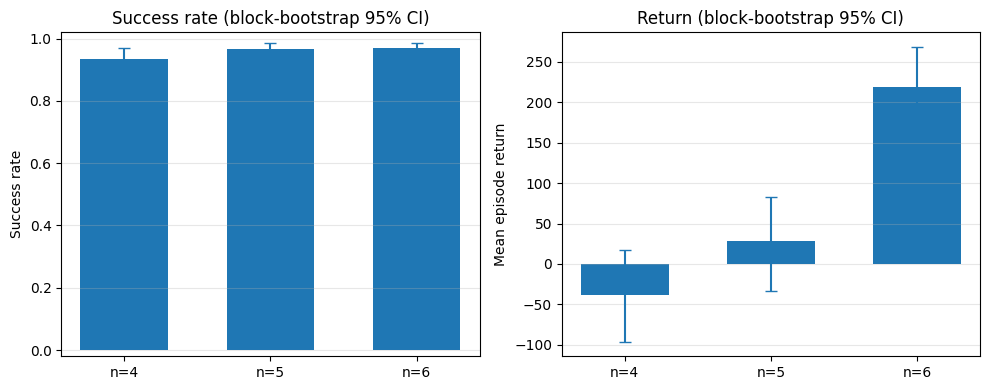

In [21]:
# Jupyter cell C — Block-bootstrap CIs for final metrics (per n)
# Inputs: result4.csv, result5.csv, result6.csv
# Uses circular block bootstrap over the last LAST_EPISODES episodes to account for episode-to-episode correlation.
# Metrics:
#   • success_rate
#   • mean_completion_time (successful episodes only)
#   • mean_episode_return (scaled reward with [1,1,0,10,10,10,1,1,1])

import os, re, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}

LAST_EPISODES = 200
BLOCK_SIZE = 20          # episodes per block (tune to your correlation length)
N_BOOT = 2000            # number of bootstrap replicates
ALPHA = 0.05

REWARD_SCALE = np.array([1., 1., 0., 10., 10., 10., 1., 1., 1.], dtype=float)
COMP_RE = re.compile(r"agent(\d+)_comp(\d+)$")

def last_k(df, k):
    if k is None: return df
    eps = np.array(sorted(df["episode_id"].unique()))
    keep = eps[-min(k, len(eps)):]
    return df[df["episode_id"].isin(keep)]

def infer_n_agents(df):
    ids = []
    for c in df.columns:
        m = COMP_RE.match(c)
        if m: ids.append(int(m.group(1)))
    return (max(ids) + 1) if ids else 0

def per_episode_return(df, expected_n=None):
    n = infer_n_agents(df)
    step_total = np.zeros(len(df), dtype=float)
    for i in range(n):
        comps = []
        for k in range(1,10):
            col = f"agent{i}_comp{k}"
            if col in df.columns:
                comps.append(df[col].to_numpy(float))
            else:
                comps.append(np.zeros(len(df)))
        comps = np.vstack(comps)
        step_total += (REWARD_SCALE[:, None] * comps).sum(axis=0)
    s = pd.Series(step_total, index=df.index)
    return s.groupby(df["episode_id"]).sum().sort_index()

def success_and_completion(df, n):
    need = {"episode_id","timestep","done_count"}
    if not need.issubset(df.columns):
        miss = sorted(list(need - set(df.columns)))
        raise ValueError(f"Missing columns: {miss}")
    df = df.sort_values(["episode_id","timestep"]).reset_index(drop=True)
    g = df.groupby("episode_id", sort=True)
    success = (g["done_count"].max() >= n).astype(int)
    def first_done(gr):
        idx = gr.index[gr["done_count"] >= n]
        return np.nan if len(idx)==0 else float(gr.loc[idx[0], "timestep"])
    ctime = g.apply(first_done)
    return pd.DataFrame({"success": success, "completion_time": ctime})

def circular_block_bootstrap_indices(E, B, rng):
    """Return a length-E index array sampled by concatenating random blocks of size B (wrap-around)."""
    n_blocks = math.ceil(E / B)
    starts = rng.integers(0, E, size=n_blocks)
    idx = []
    for s in starts:
        block = [(s + i) % E for i in range(B)]
        idx.extend(block)
    return np.array(idx[:E])

rng = np.random.default_rng(12345)

# ---- Collect per-episode tables for each n ----
metrics = {}  # n -> DataFrame with columns [return, success, completion_time]
for n, path in FILES.items():
    if not os.path.exists(path):
        print(f"WARNING: {path} not found; skipping n={n}")
        continue
    df = pd.read_csv(path)
    df=df[df['episode_id'] <=1000]
    df = last_k(df, LAST_EPISODES)
    ep_ret = per_episode_return(df, expected_n=n)
    sc = success_and_completion(df, n)
    eps = sorted(set(ep_ret.index).union(sc.index))
    tab = pd.DataFrame({
        "return": ep_ret.reindex(eps).to_numpy(float),
        "success": sc.reindex(eps)["success"].to_numpy(float),
        "completion_time": sc.reindex(eps)["completion_time"].to_numpy(float),
    }, index=pd.Index(eps, name="episode_id"))
    metrics[n] = tab

# ---- Bootstrap ----
summary = {}
for n, tab in metrics.items():
    E = len(tab)
    if E == 0:
        continue
    # point estimates
    succ_rate = np.nanmean(tab["success"].to_numpy())
    comp_times = tab.loc[tab["success"]==1, "completion_time"].dropna().to_numpy()
    mean_comp = np.nan if len(comp_times)==0 else np.mean(comp_times)
    mean_ret  = np.nanmean(tab["return"].to_numpy())
    # bootstrap
    succ_samples, comp_samples, ret_samples = [], [], []
    for _ in range(N_BOOT):
        idx = circular_block_bootstrap_indices(E, BLOCK_SIZE, rng)
        b = tab.iloc[idx]
        succ_samples.append(np.nanmean(b["success"].to_numpy()))
        ret_samples.append(np.nanmean(b["return"].to_numpy()))
        ct = b.loc[b["success"]==1, "completion_time"].dropna().to_numpy()
        comp_samples.append(np.nan if len(ct)==0 else np.mean(ct))
    succ_ci = (np.nanpercentile(succ_samples, 100*ALPHA/2),
               np.nanpercentile(succ_samples, 100*(1-ALPHA/2)))
    ret_ci  = (np.nanpercentile(ret_samples, 100*ALPHA/2),
               np.nanpercentile(ret_samples, 100*(1-ALPHA/2)))
    comp_ci = (np.nanpercentile([x for x in comp_samples if not np.isnan(x)], 100*ALPHA/2)
               if not all(np.isnan(comp_samples)) else np.nan,
               np.nanpercentile([x for x in comp_samples if not np.isnan(x)], 100*(1-ALPHA/2))
               if not all(np.isnan(comp_samples)) else np.nan)
    summary[n] = {
        "success_rate": succ_rate, "success_ci_lo": succ_ci[0], "success_ci_hi": succ_ci[1],
        "mean_return": mean_ret,   "return_ci_lo":  ret_ci[0],   "return_ci_hi":  ret_ci[1],
        "mean_completion": mean_comp, "comp_ci_lo": comp_ci[0],  "comp_ci_hi": comp_ci[1],
        "episodes": E
    }

# ---- Present ----
df_sum = pd.DataFrame.from_dict(summary, orient="index").sort_index()
print("Block-bootstrap summary over last {} episodes (block size = {}, B = {}):".format(LAST_EPISODES, BLOCK_SIZE, N_BOOT))
print(df_sum)

# Bar plots with CIs (success rate and mean return). Add completion-time plot if desired.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ns = list(df_sum.index)
x = np.arange(len(ns))

# Success rate
y = df_sum["success_rate"].to_numpy()
lo = df_sum["success_ci_lo"].to_numpy()
hi = df_sum["success_ci_hi"].to_numpy()
yerr = np.vstack([y - lo, hi - y])
ax1.bar(x, y, width=0.6)
ax1.errorbar(x, y, yerr=yerr, fmt="none", capsize=4, linewidth=1.5)
ax1.set_xticks(x, [f"n={n}" for n in ns])
ax1.set_ylim(-0.02, 1.02)
ax1.set_ylabel("Success rate")
ax1.set_title("Success rate (block-bootstrap 95% CI)")
ax1.grid(axis="y", alpha=0.3)

# Mean return
y = df_sum["mean_return"].to_numpy()
lo = df_sum["return_ci_lo"].to_numpy()
hi = df_sum["return_ci_hi"].to_numpy()
yerr = np.vstack([y - lo, hi - y])
ax2.bar(x, y, width=0.6)
ax2.errorbar(x, y, yerr=yerr, fmt="none", capsize=4, linewidth=1.5)
ax2.set_xticks(x, [f"n={n}" for n in ns])
ax2.set_ylabel("Mean episode return")
ax2.set_title("Return (block-bootstrap 95% CI)")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figureC_bootstrap.png", dpi=600, bbox_inches="tight")
plt.savefig("figureC_bootstrap.pdf", bbox_inches="tight")
print("Saved: figureC_bootstrap.png/.pdf")


In [22]:
# Jupyter cell — Compute metrics for comparison tables (n = 4, 5, 6)
# -----------------------------------------------------------------------------
# This cell computes the SAME variables you can place into the comparison tables:
#   • SR (%)              : Success Rate = % episodes where all n agents reached goals
#   • MS (steps)          : Makespan = mean steps-to-full-completion (successful episodes only)
#   • CR (per step)       : Agent–agent collision rate per step (if per-collision penalty is known)
#   • CR_penalty_per_step : Fallback when collision *counts* are not available; uses penalty magnitude per step
#
# Files expected (same folder as notebook):
#   result4.csv, result5.csv, result6.csv
#
# Assumptions / Notes:
#   • An episode is a SUCCESS iff at any step `done_count == n`.
#   • Completion time (makespan) = first `timestep` where `done_count == n`.
#   • Collision component is `agent{i}_comp5` (agent–agent collisions).
#   • Obstacle collisions (component 6) are ignored (not present).
#   • Your reward scale for components is: [1, 1, 0, 10, 10, 10, 1, 1, 1]
#       → specifically comp5 is scaled ×10, and comp6 is ignored.
#
# How collision rate (CR) is computed:
#   1) We sum the SCALED penalty for comp5 over agents & timesteps per episode.
#   2) If you KNOW the base penalty per collision EVENT (UNSCALED), set COLLISION_EVENT_PENALTY_UNSCALED below
#      (e.g., -1.0 if each collision applies -1 before scaling).
#      Then: estimated collisions = positive_magnitude_of_scaled_sum / (abs(COLLISION_EVENT_PENALTY_UNSCALED) * 10)
#      and CR = (collisions per episode) / (episode steps).
#   3) If you do NOT know the per-event penalty, we report CR_penalty_per_step (penalty magnitude per step),
#      which is comparable within your runs but not a count.
#
# Output:
#   • Prints a small table for n=4,5,6
#   • Saves CSV with all metrics: 'comparison_metrics.csv'
# -----------------------------------------------------------------------------

import os
import re
import numpy as np
import pandas as pd

# ---------------- Config ----------------
FILES = {4: "result4.csv", 5: "result5.csv", 6: "result6.csv"}

# Use the final K episodes to represent "evaluation". Set to None to use ALL episodes.
LAST_EPISODES = 200

# If you know the per-collision event penalty BEFORE scaling (negative value), set here.
# Example: if each collision adds -1.0 to comp5 before scaling, set -1.0.
# If unknown, leave as None to skip CR (count) and report CR_penalty_per_step instead.
COLLISION_EVENT_PENALTY_UNSCALED = None  # e.g., -1.0  (leave None if unknown)

# Component 5 (agent–agent collision) scale is ×10 in your setup:
COMP5_SCALE = 10.0

# ---------------- Helpers ----------------
COMP_COL_RE = re.compile(r"agent(\d+)_comp(\d+)$")

def need_cols(df, path, cols):
    missing = set(cols) - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns: {sorted(missing)}")

def last_k(df: pd.DataFrame, k: int | None):
    if k is None:
        return df
    eps = np.array(sorted(df["episode_id"].unique()))
    keep = eps[-min(k, len(eps)):]
    return df[df["episode_id"].isin(keep)]

def infer_n_agents(df: pd.DataFrame) -> int:
    ids = []
    for c in df.columns:
        m = COMP_COL_RE.match(c)
        if m:
            ids.append(int(m.group(1)))
    return (max(ids) + 1) if ids else 0

def success_and_makespan(df: pd.DataFrame, n: int) -> pd.DataFrame:
    """
    Returns DataFrame indexed by episode_id with:
      success (0/1), completion_time (first timestep where done_count==n or NaN if never),
      ep_steps (max timestep observed in the episode).
    """
    need_cols(df, "<in-memory>", ["episode_id", "timestep", "done_count"])
    df = df.sort_values(["episode_id", "timestep"]).reset_index(drop=True)
    g = df.groupby("episode_id", sort=True)

    # success flag per episode
    success = (g["done_count"].max() >= n).astype(int)

    # first timestep where all agents are done
    def first_all_done(gr):
        idx = gr.index[gr["done_count"] >= n]
        return np.nan if len(idx) == 0 else float(gr.loc[idx[0], "timestep"])

    completion_time = g.apply(first_all_done)
    ep_steps = g["timestep"].max().astype(float)

    out = pd.DataFrame({"success": success, "completion_time": completion_time, "ep_steps": ep_steps})
    out.index.name = "episode_id"
    return out

def collision_penalty_per_episode(df: pd.DataFrame, n_expected: int | None = None) -> pd.Series:
    """
    Returns a Series indexed by episode_id with the SCALED agent–agent collision penalty SUM per episode.
    Positive magnitude can be obtained by taking (-value).clip(lower=0).
    """
    n_agents = infer_n_agents(df)
    if n_expected and n_agents and (n_agents != n_expected):
        pass  # proceed anyway

    # Collect comp5 columns for all detected agents
    comp5_cols = [f"agent{i}_comp5" for i in range(n_agents) if f"agent{i}_comp5" in df.columns]
    if not comp5_cols:
        # No comp5 columns → zero penalty
        per_step_scaled = np.zeros(len(df), dtype=float)
    else:
        raw_sum = df[comp5_cols].sum(axis=1).to_numpy(float)
        per_step_scaled = COMP5_SCALE * raw_sum  # apply ×10 scaling

    s = pd.Series(per_step_scaled, index=df.index, name="comp5_scaled_sum")
    per_ep = s.groupby(df["episode_id"]).sum().sort_index()
    return per_ep  # typically negative or zero

def compute_metrics_for_file(path: str, n: int, last_eps: int | None):
    df = pd.read_csv(path)
    df=df[df['episode_id'] <=1000]
    need_cols(df, path, ["episode_id", "timestep", "done_count"])
    # Restrict to final K episodes if requested
    df_eval = last_k(df, last_eps)

    # Success & makespan
    sm = success_and_makespan(df_eval, n)
    total_eps = sm.shape[0]
    successes = int(sm["success"].sum())
    sr = (successes / total_eps) * 100.0 if total_eps > 0 else np.nan  # in %

    # Makespan (successful episodes only)
    ms_series = sm.loc[sm["success"] == 1, "completion_time"].dropna().astype(float)
    ms_mean = ms_series.mean() if len(ms_series) else np.nan
    ms_std  = ms_series.std(ddof=1) if len(ms_series) > 1 else np.nan
    ms_median = ms_series.median() if len(ms_series) else np.nan

    # Collision metrics
    comp5_per_ep = collision_penalty_per_episode(df_eval, n_expected=n)  # scaled sums per episode (likely ≤ 0)
    # Positive magnitude of penalty per episode:
    comp5_mag = (-comp5_per_ep).clip(lower=0.0)

    # Episode length for rate calculation
    ep_steps = sm["ep_steps"].reindex(comp5_mag.index).astype(float)

    # Penalty magnitude per step (always available)
    cr_penalty_per_step_ep = comp5_mag / ep_steps.replace(0, np.nan)
    cr_penalty_per_step = cr_penalty_per_step_ep.mean()

    # Collision COUNT per step (only if you know the per-event penalty before scaling)
    if COLLISION_EVENT_PENALTY_UNSCALED is not None and COLLISION_EVENT_PENALTY_UNSCALED != 0:
        per_event_scaled = abs(COLLISION_EVENT_PENALTY_UNSCALED) * COMP5_SCALE
        collisions_per_ep = comp5_mag / per_event_scaled  # estimated event count
        cr_count_per_step_ep = collisions_per_ep / ep_steps.replace(0, np.nan)
        cr_count_per_step = cr_count_per_step_ep.mean()
    else:
        cr_count_per_step = np.nan  # not available without per-event penalty

    return {
        "n": n,
        "episodes_considered": total_eps,
        "successes": successes,
        "SR_percent": sr,
        "MS_steps_mean": ms_mean,
        "MS_steps_std": ms_std,
        "MS_steps_median": ms_median,
        "CR_per_step": cr_count_per_step,            # collisions per step (requires per-event penalty)
        "CR_penalty_per_step": cr_penalty_per_step,  # fallback: penalty magnitude per step
    }

# ---------------- Run for all n and save ----------------
rows = []
for n, path in FILES.items():
    if not os.path.exists(path):
        print(f"WARNING: '{path}' not found. Skipping n={n}.")
        continue
    rows.append(compute_metrics_for_file(path, n, LAST_EPISODES))

if not rows:
    raise SystemExit("No CSV files found. Place result4.csv, result5.csv, result6.csv next to this notebook and rerun.")

tbl = pd.DataFrame(rows).set_index("n").sort_index()

# Round a few for presentation (you can keep full precision if you prefer)
rounded = tbl.copy()
rounded["SR_percent"] = rounded["SR_percent"].round(1)
rounded["MS_steps_mean"] = rounded["MS_steps_mean"].round(1)
rounded["MS_steps_std"] = rounded["MS_steps_std"].round(1)
rounded["MS_steps_median"] = rounded["MS_steps_median"].round(1)
rounded["CR_per_step"] = rounded["CR_per_step"].round(4)
rounded["CR_penalty_per_step"] = rounded["CR_penalty_per_step"].round(4)

print(f"Evaluation window: last {LAST_EPISODES if LAST_EPISODES is not None else 'ALL'} episodes\n")
print(rounded[[
    "episodes_considered", "successes", "SR_percent",
    "MS_steps_mean", "MS_steps_std", "MS_steps_median",
    "CR_per_step", "CR_penalty_per_step"
]])

# Save full-precision CSV to include in your workflow if needed
tbl.to_csv("comparison_metrics.csv", index=True)
print("\nSaved: comparison_metrics.csv")

# ------------------------------------------------------------------
# How to place into your tables:
#   • Table A (n=4): use SR_percent and MS_steps_mean (report ± MS_steps_std if desired).
#   • Table B (n=5): use SR_percent, MS_steps_mean, and CR_per_step (if you set COLLISION_EVENT_PENALTY_UNSCALED).
#       If you do not know the per-event penalty, report CR_penalty_per_step in the text as a proxy,
#       and do NOT claim equivalence to “collision rate” from other papers.
# ------------------------------------------------------------------


C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\3193171370.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  completion_time = g.apply(first_all_done)
C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\3193171370.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  completion_time = g.apply(first_all_done)


Evaluation window: last 200 episodes

   episodes_considered  successes  SR_percent  MS_steps_mean  MS_steps_std  \
n                                                                            
4                  200        187        93.5           97.3          94.4   
5                  200        193        96.5           89.2          82.2   
6                  200        194        97.0           58.3          60.2   

   MS_steps_median  CR_per_step  CR_penalty_per_step  
n                                                     
4             59.0          NaN               0.2443  
5             59.0          NaN               0.3163  
6             40.5          NaN               0.6410  

Saved: comparison_metrics.csv


C:\Users\abzza\AppData\Local\Temp\ipykernel_28272\3193171370.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  completion_time = g.apply(first_all_done)


In [23]:
# Jupyter cell — recompute final-window metrics with collision metrics derived from comp5
# Do NOT run here; run in your own notebook with your CSVs present.

import pandas as pd
from pathlib import Path
import numpy as np

# Files (adjust paths if needed)
files = {
    4: "result4.csv",
    5: "result5.csv",
    6: "result6.csv",
}

# Reward scales (by component index k = 1..9). We ignore comp3 (scale=0) and comp6 (no obstacles).
SCALES = {1:1.0, 2:1.0, 3:0.0, 4:10.0, 5:10.0, 6:10.0, 7:1.0, 8:1.0, 9:1.0}
ALPHA_COLLISION = SCALES[5]
TOL = 1e-12  # numerical tolerance for "nonzero" checks

def infer_agent_indices(columns, key_prefix):
    """Infer agent indices present by scanning column names like 'agent3_comp5' or 'hung_dist_agent2'."""
    idx = set()
    for c in columns:
        if c.startswith(key_prefix):
            # key_prefix like 'agent' or 'hung_dist_agent'
            # extract the integer that follows the prefix up to next underscore/digits
            s = c[len(key_prefix):]
            # examples of s: '0_comp5', '3_vel_lin', '2'
            num = ''
            for ch in s:
                if ch.isdigit():
                    num += ch
                else:
                    break
            if num != '':
                idx.add(int(num))
    if not idx:
        # fallback: try 'agent0_comp5' style only
        for a in range(32):  # arbitrary upper bound
            if f"agent{a}_comp5" in columns:
                idx.add(a)
    return sorted(idx)

def compute_episode_metrics(df, n_expected=None):
    """
    Compute per-episode metrics, including:
      - success indicator (strict: done_count reaches n at any timestep)
      - episode length (steps)
      - collision_step_rate: steps with any collision penalty / steps
      - collision_penalty_per_step: mean per-step magnitude of scaled collision penalty
      - scaled episode return (using SCALES)
      - completion time (first timestep where done_count == n), NaN if never reaches n
    """
    # Infer agent indices for comp5
    agents = infer_agent_indices(df.columns, "agent")
    # restrict to those that actually have comp5
    agents = [a for a in agents if f"agent{a}_comp5" in df.columns]
    if n_expected is None:
        n = len(agents)
    else:
        n = n_expected

    # Build a vectorized series: per-row total scaled collision penalty across agents
    coll_cols = [f"agent{a}_comp5" for a in agents]
    for c in coll_cols:
        df[c] = df[c].fillna(0.0)
    total_scaled_collision = ALPHA_COLLISION * df[coll_cols].sum(axis=1)

    # any collision occurred at this timestep? (penalty convention: negative values)
    # Use != 0 with tolerance to be robust to logging noise.
    collision_any_step = (np.abs(total_scaled_collision) > TOL)

    # Group by episode
    g = df.groupby("episode_id", sort=True, observed=True)

    records = []
    for ep, gdf in g:
        steps = int(gdf["timestep"].max())  # 'timestep' is 1..T; this returns T
        if steps <= 0:
            continue

        # success: did done_count ever reach n?
        success = bool((gdf["done_count"] >= n).any())

        # completion time: first t with done_count == n (NaN if never)
        comp_time = np.nan
        hit = gdf.loc[gdf["done_count"] >= n, "timestep"]
        if not hit.empty:
            comp_time = int(hit.iloc[0])

        # collision metrics
        coll_steps = int(collision_any_step.loc[gdf.index].sum())
        collision_step_rate = coll_steps / steps

        # average per-step magnitude of scaled collision penalty (positive magnitude)
        coll_penalty_series = -np.minimum(total_scaled_collision.loc[gdf.index], 0.0)
        collision_penalty_per_step = float(coll_penalty_series.sum() / steps)

        # scaled episode return from component columns (ignore comp3 and comp6 by their scales)
        ep_return = 0.0
        for a in agents:
            for k in range(1, 10):
                alpha = SCALES.get(k, 0.0)
                if alpha == 0.0:
                    continue
                col = f"agent{a}_comp{k}"
                if col in gdf:
                    ep_return += float(alpha * gdf[col].sum())

        records.append({
            "episode_id": ep,
            "n": n,
            "steps": steps,
            "success": int(success),
            "completion_time": comp_time,
            "collision_step_rate": collision_step_rate,
            "collision_penalty_per_step": collision_penalty_per_step,
            "episode_return_scaled": ep_return,
        })

    return pd.DataFrame.from_records(records).sort_values("episode_id").reset_index(drop=True)

def metrics_last_window(per_ep_df, window=200):
    """Aggregate metrics over the last `window` episodes."""
    dfw = per_ep_df.tail(window).copy()
    n = int(dfw["n"].iloc[0]) if not dfw.empty else np.nan
    N = len(dfw)
    successes = int(dfw["success"].sum())
    success_rate = successes / N if N > 0 else np.nan

    # completion time on successful episodes only
    comp_times = dfw.loc[dfw["success"] == 1, "completion_time"].dropna().to_numpy()
    avg_comp = float(np.mean(comp_times)) if comp_times.size else np.nan
    std_comp = float(np.std(comp_times, ddof=1)) if comp_times.size > 1 else np.nan

    # return
    rets = dfw["episode_return_scaled"].to_numpy()
    avg_ret = float(np.mean(rets)) if rets.size else np.nan
    std_ret = float(np.std(rets, ddof=1)) if rets.size > 1 else np.nan

    # collision metrics
    cr = float(dfw["collision_step_rate"].mean()) if N > 0 else np.nan
    cr_pen = float(dfw["collision_penalty_per_step"].mean()) if N > 0 else np.nan

    return {
        "n": n, "episodes_considered": N, "successes": successes,
        "success_rate": success_rate,
        "avg_completion_time_steps": avg_comp, "completion_time_std": std_comp,
        "avg_return": avg_ret, "return_std": std_ret,
        "collision_step_rate": cr,
        "collision_penalty_per_step": cr_pen,
    }

# ---- main pass ----
all_summaries = []
per_episode_frames = {}

for n, path in files.items():
    df = pd.read_csv(path)
    df=df[df['episode_id'] <=1000]

    per_ep = compute_episode_metrics(df, n_expected=n)
    per_episode_frames[n] = per_ep
    all_summaries.append(metrics_last_window(per_ep, window=200))

summary_df = pd.DataFrame(all_summaries).set_index("n").sort_index()
print(summary_df)

# Optional: save per-episode metrics and the summary to CSV for the paper’s tables
# for n, per_ep in per_episode_frames.items():
#     per_ep.to_csv(f"per_episode_metrics_n{n}.csv", index=False)
# summary_df.to_csv("final_window_summary_with_collisions.csv")


   episodes_considered  successes  success_rate  avg_completion_time_steps  \
n                                                                            
4                  200        187         0.935                  97.342246   
5                  200        193         0.965                  89.160622   
6                  200        194         0.970                  58.304124   

   completion_time_std  avg_return  return_std  collision_step_rate  \
n                                                                     
4            94.382489  -38.953713  461.518735             0.081010   
5            82.166308   27.900159  480.079073             0.106027   
6            60.172854  219.111901  406.723839             0.201136   

   collision_penalty_per_step  
n                              
4                    0.244302  
5                    0.316304  
6                    0.640976  


In [28]:
# Create two bar charts (one per dataset) with a descriptive legend text box.
import matplotlib.pyplot as plt

# Data for IV-2a
models_2a = [
    "Ours (ConvoReleNet+TL)",
    "CIACNet (Liao 2025)",
    "EEGNet v4 (Lawhern 2018)",
    "SVM-SA (Otarbay 2025)",
    "EEG-Conformer (SI) (Song 2023)"
]
acc_2a = [87.55, 85.15, 77.12, 77.43, 72.41]

# Plot IV-2a
plt.figure(figsize=(10,6))
bars = plt.bar(models_2a, acc_2a)
plt.ylabel("Accuracy (%)")
plt.title("SOTA Comparison on BNCI 2008–IV-2a")
plt.ylim(60, 95)
plt.xticks(rotation=20, ha='right')

# Annotate bar values
for b in bars:
    height = b.get_height()
    plt.text(b.get_x() + b.get_width()/2., height + 0.5, f"{height:.2f}%", ha='center', va='bottom', fontsize=9)

# legend_text_2a = (
#     "Legend: Bars show explicitly reported accuracies. Our model uses transfer learning (subject-independent).\n"
#     "CIACNet: attention-enhanced CNN (Liao 2025). EEGNet v4: compact CNN baseline (Lawhern 2018).\n"
#     "SVM-SA: SVM-enhanced self-attention with LOSO (Otarbay 2025). EEG-Conformer: subject-independent accuracy (Song 2023)."
# )
# plt.gcf().text(0.5, 0.01, legend_text_2a, ha='center', va='bottom', fontsize=9, wrap=True)

plt.tight_layout(rect=[0,0.05,1,1])
plt.savefig("SOTA_IV2a.png", dpi=300, bbox_inches="tight")
plt.close()

# Data for IV-2b
models_2b = [
    "Ours (ConvoReleNet+TL)",
    "CNN-GRU (Xu 2021)",
    "Multi-Branch CNN (Chowdhury 2023)",
    "CIACNet (Liao 2025)",
    "SVM-SA (Otarbay 2025)"
]
acc_2b = [83.85, 87.64, 84.13, 82.00, 81.47]

# Plot IV-2b
plt.figure(figsize=(10,6))
bars = plt.bar(models_2b, acc_2b)
plt.ylabel("Accuracy (%)")
plt.title("SOTA Comparison on BNCI 2008–IV-2b")
plt.ylim(75, 92)
plt.xticks(rotation=20, ha='right')

for b in bars:
    height = b.get_height()
    plt.text(b.get_x() + b.get_width()/2., height + 0.4, f"{height:.2f}%", ha='center', va='bottom', fontsize=9)

# legend_text_2b = (
#     "Legend: Explicitly reported accuracies only. Our model uses transfer learning (subject-independent).\n"
#     "CNN-GRU (Xu 2021) is the strongest report here. Multi-Branch CNN from Chowdhury 2023 is close to ours.\n"
#     "CIACNet (Liao 2025) and SVM-SA (Otarbay 2025) are attention-based CNN/self-attention baselines."
# )
# plt.gcf().text(0.5, 0.01, legend_text_2b, ha='center', va='bottom', fontsize=9, wrap=True)

plt.tight_layout(rect=[0,0.05,1,1])
plt.savefig("SOTA_IV2b.png", dpi=300, bbox_inches="tight")
plt.close()

# "/mnt/data/SOTA_IV2a.png", "/mnt/data/SOTA_IV2b.png"
